## Monster × VIDEO ELAIS-S1 cross-match — Approach 2

This notebook builds the **Approach 2** VIRCAM reference catalogue for the DP2 ELAIS-S1 tests.

Approach 2 changes only the origin of the VIRCAM Z/Y reference photometry:

- **Z and Y:** derived from the calibrated Monster-to-VISTA colour transformations stored in the final YAML files;
- **J, H, and Ks:** taken from VIDEO DR5 using exactly the same astrometric matching procedure as Approach 1;
- **astrometry:** taken from Monster and written unchanged to the output.

The final output schema is the same minimal VIRCAM reference-catalogue schema used in Approach 1. No Monster optical photometric field is copied into the output. The DES fields specified by the YAML files are used only internally to evaluate the Z/Y transformations.

Several safeguards are included because the Z/Y transformations are the scientifically important difference between the two approaches:

- the exact Z and Y YAML filenames are used rather than heuristic file discovery;
- the YAML metadata are validated before any transformation is applied;
- the Z relation must use DES $i-z$ and DES $z$ as the source flux;
- the Y relation must use DES $z-y$ and DES $y$ as the source flux;
- the stored relation is interpreted as $R = F_{\rm Monster}/F_{\rm VIRCAM}$, so the target VIRCAM flux is recovered by **division**;
- transformation colours are accepted only inside the calibrated YAML node range;
- spline extrapolation is disabled explicitly; and
- J/H/Ks and the match separation are compared directly with Approach 1 as an end-to-end consistency check.

The effective VIDEO matching epoch is fixed to **2006.7**, the value determined reproducibly by the coarse and fine epoch scans in the Approach 1 notebook. The same epoch is reused here because the VIDEO J/H/Ks cross-match is intentionally identical.

### Imports

In [1]:
from pathlib import Path

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import yaml

from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table
from astropy.time import Time

from scipy.interpolate import CubicSpline

import lsst.afw.table as afwTable
from lsst.geom import SpherePoint, radians

### Input and output configuration

The notebook is intended to be run from `dmu2/dmu2_DP2`.

The final transformation YAML files are stored in the neighbouring `dmu2/Monster` directory. Their filenames are specified explicitly so that a future additional YAML file cannot be selected accidentally.

In [2]:
monster_dir = Path(
    "data/the_monster_20250219/ELAIS1"
)

vista_file = Path(
    "data/NIR-Catalogs/video-elais-dr5.fits"
)

calibration_dir = Path(
    "../Monster"
)

z_yaml = (
    calibration_dir
    / "Monster_to_VISTA_band_z.yaml"
)

y_yaml = (
    calibration_dir
    / "Monster_to_VISTA_band_y.yaml"
)

outdir = Path(
    "data/video_elais_ap2/the_monster_20250219_vista"
)
outdir.mkdir(
    parents=True,
    exist_ok=True,
)

ap1_dir = Path(
    "data/video_elais/the_monster_20250219_vista"
)

monster_files = sorted(
    monster_dir.glob(
        "refcat_htm7_*.fits"
    )
)

if not monster_files:
    raise FileNotFoundError(
        f"No Monster HTM7 shards found in {monster_dir}"
    )

for required_file in [
    vista_file,
    z_yaml,
    y_yaml,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            required_file
        )

htm7_ids = [
    int(
        path.stem.split("_")[-1]
    )
    for path in monster_files
]

monster_path_by_id = {
    int(
        path.stem.split("_")[-1]
    ): path
    for path in monster_files
}

print(
    f"Monster shards: {len(htm7_ids)}"
)
print(htm7_ids)

print(
    f"\nVIDEO catalogue: {vista_file}"
)
print(
    f"Z transformation: {z_yaml}"
)
print(
    f"Y transformation: {y_yaml}"
)
print(
    f"Output directory: {outdir}"
)

Monster shards: 24
[145428, 145448, 145449, 145451, 145456, 145620, 145621, 145622, 145623, 145626, 145628, 145630, 145631, 145640, 145642, 145643, 145648, 145649, 145650, 145651, 145657, 145661, 145662, 145663]

VIDEO catalogue: data/NIR-Catalogs/video-elais-dr5.fits
Z transformation: ../Monster/Monster_to_VISTA_band_z.yaml
Y transformation: ../Monster/Monster_to_VISTA_band_y.yaml
Output directory: data/video_elais_ap2/the_monster_20250219_vista


### Load and validate the Z/Y calibration YAML files

The final calibrations store a colour-dependent flux ratio.

For Z,

$$
R_Z(i-z)
=
\frac{F_{{\rm DES},z}}
     {F_{{\rm VIRCAM},Z}},
$$

and therefore

$$
F_{{\rm VIRCAM},Z}
=
\frac{F_{{\rm DES},z}}
     {R_Z(i-z)}.
$$

For Y,

$$
R_Y(z-y)
=
\frac{F_{{\rm DES},y}}
     {F_{{\rm VIRCAM},Y}},
$$

and therefore

$$
F_{{\rm VIRCAM},Y}
=
\frac{F_{{\rm DES},y}}
     {R_Y(z-y)}.
$$

The validation below is intentionally strict. In particular, it prevents the Y-band transformation from accidentally using the Z-band colour fields or an older VIKING YAML definition.

In [3]:
with z_yaml.open() as stream:
    z_payload = yaml.safe_load(
        stream
    )

with y_yaml.open() as stream:
    y_payload = yaml.safe_load(
        stream
    )


EXPECTED_TRANSFORMS = {
    "Z": {
        "source_survey": "Monster",
        "target_survey": "VISTA",
        "source_field": "monster_DES_z_flux",
        "source_color_field_1": "monster_DES_i_flux",
        "source_color_field_2": "monster_DES_z_flux",
    },
    "Y": {
        "source_survey": "Monster",
        "target_survey": "VISTA",
        "source_field": "monster_DES_y_flux",
        "source_color_field_1": "monster_DES_z_flux",
        "source_color_field_2": "monster_DES_y_flux",
    },
}


def validate_transform_yaml(
    payload,
    expected,
    band,
):
    """Validate one final Monster-to-VISTA calibration YAML."""

    required_keys = [
        "flux_offset",
        "nodes",
        "spline_values",
        "source_field",
        "source_color_field_1",
        "source_color_field_2",
        "source_survey",
        "target_survey",
    ]

    missing = [
        key
        for key in required_keys
        if key not in payload
    ]

    if missing:
        raise KeyError(
            f"{band} YAML is missing keys: "
            + ", ".join(
                missing
            )
        )

    for key, expected_value in expected.items():

        actual_value = payload[
            key
        ]

        if actual_value != expected_value:
            raise ValueError(
                f"{band} YAML: {key} = "
                f"{actual_value!r}, expected "
                f"{expected_value!r}"
            )

    flux_offset = float(
        payload[
            "flux_offset"
        ]
    )

    if flux_offset != 0.0:
        raise NotImplementedError(
            f"{band} YAML has non-zero flux_offset="
            f"{flux_offset}. This notebook implements "
            "the current zero-offset calibration only."
        )

    nodes = np.asarray(
        payload[
            "nodes"
        ],
        dtype=float,
    )

    values = np.asarray(
        payload[
            "spline_values"
        ],
        dtype=float,
    )

    if (
        nodes.ndim != 1
        or values.ndim != 1
        or len(nodes) != len(values)
        or len(nodes) < 2
    ):
        raise ValueError(
            f"{band} YAML nodes/spline_values "
            "have incompatible shapes."
        )

    if (
        not np.all(
            np.isfinite(
                nodes
            )
        )
        or not np.all(
            np.isfinite(
                values
            )
        )
    ):
        raise ValueError(
            f"{band} YAML contains non-finite "
            "nodes or spline values."
        )

    if not np.all(
        np.diff(
            nodes
        )
        > 0
    ):
        raise ValueError(
            f"{band} YAML nodes must be "
            "strictly increasing."
        )

    if not np.all(
        values > 0
    ):
        raise ValueError(
            f"{band} YAML contains non-positive "
            "flux-ratio values."
        )

    spline = CubicSpline(
        nodes,
        values,
        extrapolate=False,
    )

    return {
        "payload": payload,
        "nodes": nodes,
        "values": values,
        "spline": spline,
        "color_min": float(
            nodes[0]
        ),
        "color_max": float(
            nodes[-1]
        ),
    }


z_transform = validate_transform_yaml(
    z_payload,
    EXPECTED_TRANSFORMS["Z"],
    "Z",
)

y_transform = validate_transform_yaml(
    y_payload,
    EXPECTED_TRANSFORMS["Y"],
    "Y",
)

print("Validated Z transformation:")
print(
    "  source flux : "
    f"{z_payload['source_field']}"
)
print(
    "  colour      : "
    f"{z_payload['source_color_field_1']} - "
    f"{z_payload['source_color_field_2']}"
)
print(
    "  colour range: "
    f"{z_transform['color_min']:.4f} "
    f"to {z_transform['color_max']:.4f} mag"
)

print("\nValidated Y transformation:")
print(
    "  source flux : "
    f"{y_payload['source_field']}"
)
print(
    "  colour      : "
    f"{y_payload['source_color_field_1']} - "
    f"{y_payload['source_color_field_2']}"
)
print(
    "  colour range: "
    f"{y_transform['color_min']:.4f} "
    f"to {y_transform['color_max']:.4f} mag"
)

Validated Z transformation:
  source flux : monster_DES_z_flux
  colour      : monster_DES_i_flux - monster_DES_z_flux
  colour range: 0.0000 to 0.6500 mag

Validated Y transformation:
  source flux : monster_DES_y_flux
  colour      : monster_DES_z_flux - monster_DES_y_flux
  colour range: -0.0750 to 0.1750 mag


### Inspect the stored Z transformation

The points are the stored YAML node values and the line is the cubic interpolation used by this notebook. Extrapolation is disabled.

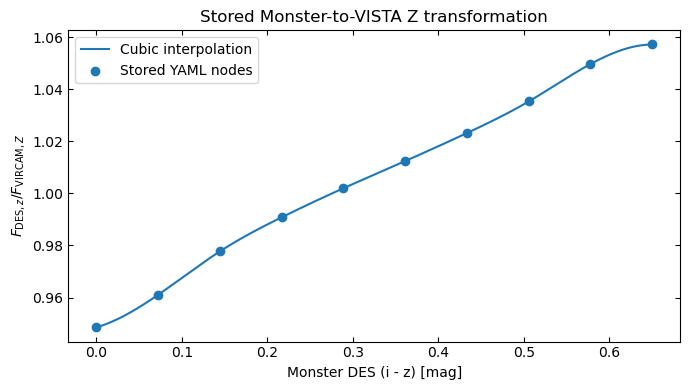

In [4]:
z_grid = np.linspace(
    z_transform[
        "color_min"
    ],
    z_transform[
        "color_max"
    ],
    500,
)

fig, ax = plt.subplots(
    figsize=(7, 4)
)

ax.plot(
    z_grid,
    z_transform[
        "spline"
    ](
        z_grid
    ),
    label="Cubic interpolation",
)

ax.scatter(
    z_transform[
        "nodes"
    ],
    z_transform[
        "values"
    ],
    label="Stored YAML nodes",
)

ax.set_xlabel(
    "Monster DES (i - z) [mag]"
)
ax.set_ylabel(
    r"$F_{\mathrm{DES},z}/F_{\mathrm{VIRCAM},Z}$"
)
ax.set_title(
    "Stored Monster-to-VISTA Z transformation"
)
ax.tick_params(
    direction="in",
    top=True,
    right=True,
)
ax.legend()

plt.tight_layout()
plt.show()

### Inspect the stored Y transformation

The Y transformation uses DES $y$ as the source flux and DES $z-y$ as the colour:

$$
z-y
=
-2.5\log_{10}
\left(
\frac{F_{{\rm DES},z}}
     {F_{{\rm DES},y}}
\right).
$$

Its calibrated colour interval is much narrower than the Z interval. No value outside the stored Y node range is accepted later in the notebook.

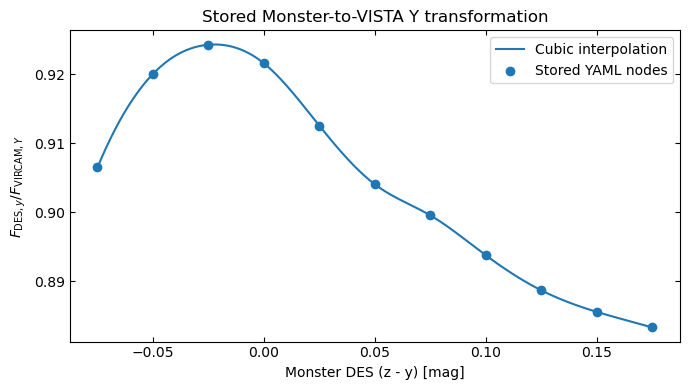

In [5]:
y_grid = np.linspace(
    y_transform[
        "color_min"
    ],
    y_transform[
        "color_max"
    ],
    500,
)

fig, ax = plt.subplots(
    figsize=(7, 4)
)

ax.plot(
    y_grid,
    y_transform[
        "spline"
    ](
        y_grid
    ),
    label="Cubic interpolation",
)

ax.scatter(
    y_transform[
        "nodes"
    ],
    y_transform[
        "values"
    ],
    label="Stored YAML nodes",
)

ax.set_xlabel(
    "Monster DES (z - y) [mag]"
)
ax.set_ylabel(
    r"$F_{\mathrm{DES},y}/F_{\mathrm{VIRCAM},Y}$"
)
ax.set_title(
    "Stored Monster-to-VISTA Y transformation"
)
ax.tick_params(
    direction="in",
    top=True,
    right=True,
)
ax.legend()

plt.tight_layout()
plt.show()

### Define VIDEO J/H/Ks columns and flux conversion

Only J, H, and Ks are taken from VIDEO in Approach 2.

VIDEO DR5 `*_FLUX_APER_2` and `*_FLUXERR_APER_2` values use an AB zeropoint of 30.0. Both fluxes and flux errors are multiplied by the same conversion factor to obtain nJy.

In [6]:
VIDEO_ZP_AB = 30.0

VIDEO_ADU_TO_NJY = (
    VIDEO_ZP_AB * u.ABmag
).to_value(
    u.nJy
)

vista_cols = [
    "KS_FLUX_APER_2",
    "KS_FLUXERR_APER_2",
    "J_FLUX_APER_2",
    "J_FLUXERR_APER_2",
    "H_FLUX_APER_2",
    "H_FLUXERR_APER_2",
]

vista_rename = {
    "KS_FLUX_APER_2": "ks_flux",
    "KS_FLUXERR_APER_2": "ks_fluxErr",
    "J_FLUX_APER_2": "j_flux",
    "J_FLUXERR_APER_2": "j_fluxErr",
    "H_FLUX_APER_2": "h_flux",
    "H_FLUXERR_APER_2": "h_fluxErr",
}

print(
    "VIDEO conversion:"
)
print(
    "1 catalogue flux unit = "
    f"{VIDEO_ADU_TO_NJY:.6f} nJy"
)

VIDEO conversion:
1 catalogue flux unit = 3.630781 nJy


### Load only the required VIDEO columns

As in Approach 1, the wide VIDEO catalogue is memory-mapped and only coordinates plus the six J/H/Ks flux/error columns are copied into memory.

In [7]:
required_vista_cols = [
    "RA2000",
    "DEC2000",
] + vista_cols

with fits.open(
    vista_file,
    memmap=True,
) as hdul:

    table_hdu = next(
        (
            hdu
            for hdu in hdul
            if isinstance(
                hdu,
                fits.BinTableHDU,
            )
            and hdu.data is not None
        ),
        None,
    )

    if table_hdu is None:
        raise RuntimeError(
            f"No binary-table HDU found in {vista_file}"
        )

    available_cols = set(
        table_hdu.columns.names
    )

    missing_vista_cols = [
        name
        for name in required_vista_cols
        if name not in available_cols
    ]

    if missing_vista_cols:
        raise KeyError(
            "Missing VIDEO columns: "
            + ", ".join(
                missing_vista_cols
            )
        )

    vista = Table(
        {
            name: np.array(
                table_hdu.data[
                    name
                ],
                copy=True,
            )
            for name
            in required_vista_cols
        }
    )

finite_coord = (
    np.isfinite(
        np.asarray(
            vista[
                "RA2000"
            ],
            dtype=float,
        )
    )
    & np.isfinite(
        np.asarray(
            vista[
                "DEC2000"
            ],
            dtype=float,
        )
    )
)

vista = vista[
    finite_coord
]

vis_coords = SkyCoord(
    ra=np.asarray(
        vista[
            "RA2000"
        ],
        dtype=float,
    ) * u.deg,
    dec=np.asarray(
        vista[
            "DEC2000"
        ],
        dtype=float,
    ) * u.deg,
)

print(
    f"VIDEO ELAIS-S1 rows retained: "
    f"{len(vista):,}"
)
print(
    f"VIDEO columns retained: "
    f"{len(vista.colnames)}"
)

VIDEO ELAIS-S1 rows retained: 842,337
VIDEO columns retained: 8


### Matching configuration

The VIDEO match is intentionally identical to Approach 1.

The effective epoch, 2006.7, was determined there from the full ELAIS-S1 Monster–VIDEO epoch scan. It is reused here so that the J/H/Ks reference measurements, match separations, and Gold sample can be compared directly between the two approaches.

In [8]:
VIDEO_EPOCH_JYEAR = 2006.7

MJD_VIDEO = Time(
    VIDEO_EPOCH_JYEAR,
    format="jyear",
).mjd

MATCH_RADIUS = (
    0.5
    * u.arcsec
)

ISO_MIN_SEP = (
    1.0
    * u.arcsec
)

VISTA_MARGIN_DEG = 0.6

print(
    f"VIDEO_EPOCH_JYEAR = "
    f"{VIDEO_EPOCH_JYEAR:.2f}"
)
print(
    f"MJD_VIDEO         = "
    f"{MJD_VIDEO:.2f}"
)
print(
    f"MATCH_RADIUS      = "
    f"{MATCH_RADIUS}"
)
print(
    f"ISO_MIN_SEP       = "
    f"{ISO_MIN_SEP}"
)

VIDEO_EPOCH_JYEAR = 2006.70
MJD_VIDEO         = 53991.68
MATCH_RADIUS      = 0.5 arcsec
ISO_MIN_SEP       = 1.0 arcsec


### Matching helper functions

These functions are kept the same as Approach 1. Proper motions are used only to propagate Monster positions for matching; original Monster astrometry is retained in the output.

In [9]:
def local_vista_cut(
    ra_deg,
    dec_deg,
    margin_deg=VISTA_MARGIN_DEG,
):
    """Select VIDEO sources near one Monster HTM7 shard."""

    ra_min = (
        np.nanmin(
            ra_deg
        )
        - margin_deg
    )
    ra_max = (
        np.nanmax(
            ra_deg
        )
        + margin_deg
    )
    dec_min = (
        np.nanmin(
            dec_deg
        )
        - margin_deg
    )
    dec_max = (
        np.nanmax(
            dec_deg
        )
        + margin_deg
    )

    return (
        (
            np.asarray(
                vista[
                    "RA2000"
                ],
                dtype=float,
            )
            > ra_min
        )
        & (
            np.asarray(
                vista[
                    "RA2000"
                ],
                dtype=float,
            )
            < ra_max
        )
        & (
            np.asarray(
                vista[
                    "DEC2000"
                ],
                dtype=float,
            )
            > dec_min
        )
        & (
            np.asarray(
                vista[
                    "DEC2000"
                ],
                dtype=float,
            )
            < dec_max
        )
    )


def monster_to_mjd_pm_only(
    mon_tbl,
    mjd_target,
):
    """Propagate Monster positions with proper motions only."""

    ra0 = np.asarray(
        mon_tbl[
            "coord_ra"
        ],
        dtype=float,
    )
    dec0 = np.asarray(
        mon_tbl[
            "coord_dec"
        ],
        dtype=float,
    )
    pmra = np.asarray(
        mon_tbl[
            "pm_ra"
        ],
        dtype=float,
    )
    pmdec = np.asarray(
        mon_tbl[
            "pm_dec"
        ],
        dtype=float,
    )
    epoch = np.asarray(
        mon_tbl[
            "epoch"
        ],
        dtype=float,
    )

    valid = (
        np.isfinite(
            ra0
        )
        & np.isfinite(
            dec0
        )
        & np.isfinite(
            pmra
        )
        & np.isfinite(
            pmdec
        )
        & np.isfinite(
            epoch
        )
        & (
            np.abs(
                np.cos(
                    dec0
                )
            )
            > 1.0e-12
        )
    )

    original_index = (
        np.flatnonzero(
            valid
        )
    )

    ra0 = ra0[
        valid
    ]
    dec0 = dec0[
        valid
    ]
    pmra = pmra[
        valid
    ]
    pmdec = pmdec[
        valid
    ]
    epoch = epoch[
        valid
    ]

    dt_year = (
        mjd_target
        - epoch
    ) / 365.25

    # pm_ra is mu_alpha* = d(alpha)/dt cos(delta).
    ra1 = (
        ra0
        + (
            pmra
            * dt_year
        )
        / np.cos(
            dec0
        )
    )

    dec1 = (
        dec0
        + pmdec
        * dt_year
    )

    finite = (
        np.isfinite(
            ra1
        )
        & np.isfinite(
            dec1
        )
    )

    coords = SkyCoord(
        ra=ra1[
            finite
        ] * u.rad,
        dec=dec1[
            finite
        ] * u.rad,
    )

    return (
        coords,
        original_index[
            finite
        ],
    )


def mutual_nn_match(
    coords_a,
    coords_b,
    radius,
):
    """Return mutual nearest-neighbour matches from A to B."""

    if (
        len(
            coords_a
        )
        == 0
        or len(
            coords_b
        )
        == 0
    ):
        return (
            np.zeros(
                len(
                    coords_a
                ),
                dtype=bool,
            ),
            np.zeros(
                len(
                    coords_a
                ),
                dtype=int,
            ),
            np.full(
                len(
                    coords_a
                ),
                np.inf,
            )
            * u.arcsec,
        )

    idx_b, sep_ab, _ = (
        match_coordinates_sky(
            coords_a,
            coords_b,
        )
    )

    within = (
        sep_ab
        < radius
    )

    candidate_b = np.unique(
        idx_b[
            within
        ]
    )

    reverse_nearest = {}

    if len(
        candidate_b
    ) > 0:

        idx_a_back, _, _ = (
            match_coordinates_sky(
                coords_b[
                    candidate_b
                ],
                coords_a,
            )
        )

        reverse_nearest = {
            int(
                b_index
            ): int(
                a_index
            )
            for b_index, a_index
            in zip(
                candidate_b,
                idx_a_back,
            )
        }

    mutual = np.fromiter(
        (
            reverse_nearest.get(
                int(
                    b_index
                ),
                -1,
            )
            == a_index
            for a_index, b_index
            in enumerate(
                idx_b
            )
        ),
        dtype=bool,
        count=len(
            idx_b
        ),
    )

    good = (
        within
        & mutual
    )

    return (
        good,
        idx_b,
        sep_ab,
    )


def isolate_mask(
    coords,
    min_sep,
):
    """Require the second-nearest Monster neighbour to be farther away."""

    if len(
        coords
    ) < 2:
        return np.ones(
            len(
                coords
            ),
            dtype=bool,
        )

    _, sep2, _ = (
        match_coordinates_sky(
            coords,
            coords,
            nthneighbor=2,
        )
    )

    return (
        sep2
        > min_sep
    )

### Define the Z/Y transformation evaluator

The colour is calculated directly from the Monster flux ratio because the relevant Monster synthetic fluxes are in the same nJy system:

$$
C
=
-2.5\log_{10}
\left(
\frac{F_1}{F_2}
\right).
$$

A transformation is evaluated only if:

- all input fluxes needed for the source and colour are finite and positive;
- the colour lies inside the exact YAML node range; and
- the interpolated Monster/VIRCAM ratio is finite and positive.

No extrapolation is allowed. The target flux is recovered by division:

$$
F_{\rm VIRCAM}
=
\frac{F_{\rm source}}{R(C)}.
$$

The target flux uncertainty is scaled by the same ratio:

$$
\sigma_{F,{\rm VIRCAM}}
=
\frac{\sigma_{F,{\rm source}}}{R(C)}.
$$

This propagates the stored Monster source-flux uncertainty only. The YAML files do not contain a colour-term uncertainty or calibration scatter, so those contributions are not added here.

In [10]:
def evaluate_transform(
    mon,
    transform,
):
    """Apply one validated Monster-to-VISTA transformation."""

    payload = transform[
        "payload"
    ]

    source_field = payload[
        "source_field"
    ]

    source_err_field = (
        source_field
        + "Err"
    )

    color1_field = payload[
        "source_color_field_1"
    ]

    color2_field = payload[
        "source_color_field_2"
    ]

    n_rows = len(
        mon
    )

    source_flux = np.asarray(
        mon[
            source_field
        ],
        dtype=float,
    )

    source_err = np.asarray(
        mon[
            source_err_field
        ],
        dtype=float,
    )

    color1_flux = np.asarray(
        mon[
            color1_field
        ],
        dtype=float,
    )

    color2_flux = np.asarray(
        mon[
            color2_field
        ],
        dtype=float,
    )

    input_valid = (
        np.isfinite(
            source_flux
        )
        & np.isfinite(
            color1_flux
        )
        & np.isfinite(
            color2_flux
        )
        & (
            source_flux
            > 0
        )
        & (
            color1_flux
            > 0
        )
        & (
            color2_flux
            > 0
        )
    )

    color = np.full(
        n_rows,
        np.nan,
        dtype=float,
    )

    color[
        input_valid
    ] = (
        -2.5
        * np.log10(
            color1_flux[
                input_valid
            ]
            / color2_flux[
                input_valid
            ]
        )
    )

    in_range = (
        input_valid
        & np.isfinite(
            color
        )
        & (
            color
            >= transform[
                "color_min"
            ]
        )
        & (
            color
            <= transform[
                "color_max"
            ]
        )
    )

    ratio = np.full(
        n_rows,
        np.nan,
        dtype=float,
    )

    ratio[
        in_range
    ] = transform[
        "spline"
    ](
        color[
            in_range
        ]
    )

    good_flux = (
        in_range
        & np.isfinite(
            ratio
        )
        & (
            ratio
            > 0
        )
    )

    good_err = (
        good_flux
        & np.isfinite(
            source_err
        )
        & (
            source_err
            >= 0
        )
    )

    target_flux = np.full(
        n_rows,
        np.nan,
        dtype=float,
    )

    target_err = np.full(
        n_rows,
        np.nan,
        dtype=float,
    )

    # Stored relation:
    # ratio = F_Monster_source / F_VIRCAM_target.
    # Therefore recover the VIRCAM target by DIVISION.
    target_flux[
        good_flux
    ] = (
        source_flux[
            good_flux
        ]
        / ratio[
            good_flux
        ]
    )

    target_err[
        good_err
    ] = (
        source_err[
            good_err
        ]
        / ratio[
            good_err
        ]
    )

    diagnostics = {
        "input_valid": input_valid,
        "color": color,
        "in_range": in_range,
        "ratio": ratio,
        "good_flux": good_flux,
        "good_err": good_err,
    }

    return (
        target_flux,
        target_err,
        diagnostics,
    )


def apply_zy_transforms(
    mon,
):
    """Apply the validated Z and Y transforms to one Monster shard."""

    (
        z2_flux,
        z2_flux_err,
        z_diag,
    ) = evaluate_transform(
        mon,
        z_transform,
    )

    (
        y2_flux,
        y2_flux_err,
        y_diag,
    ) = evaluate_transform(
        mon,
        y_transform,
    )

    values = {
        "z2_flux": z2_flux,
        "z2_fluxErr": z2_flux_err,
        "y2_flux": y2_flux,
        "y2_fluxErr": y2_flux_err,
    }

    diagnostics = {
        "Z": z_diag,
        "Y": y_diag,
    }

    return (
        values,
        diagnostics,
    )

### Load the Monster astrometric and transformation fields

Approach 2 requires the same Monster astrometric backbone as Approach 1 plus only the DES flux/error fields named by the two YAML files.

The transformation fields are derived directly from the validated YAML metadata rather than duplicated manually in the catalogue-loading code.

In [11]:
ASTROMETRY_FIELDS = [
    "id",
    "coord_ra",
    "coord_dec",
    "coord_raErr",
    "coord_decErr",
    "epoch",
    "pm_ra",
    "pm_dec",
    "pm_raErr",
    "pm_decErr",
    "parallax",
    "parallaxErr",
]


def transform_required_fields(
    payload,
):
    """Return Monster fields required by one transform."""

    source_field = payload[
        "source_field"
    ]

    return [
        source_field,
        source_field
        + "Err",
        payload[
            "source_color_field_1"
        ],
        payload[
            "source_color_field_2"
        ],
    ]


TRANSFORM_FIELDS = sorted(
    set(
        transform_required_fields(
            z_payload
        )
        + transform_required_fields(
            y_payload
        )
    )
)

MONSTER_REQUIRED_FIELDS = (
    ASTROMETRY_FIELDS
    + [
        name
        for name in TRANSFORM_FIELDS
        if name
        not in ASTROMETRY_FIELDS
    ]
)

print(
    "Transformation-only Monster fields:"
)

for name in TRANSFORM_FIELDS:
    print(
        "  ",
        name,
    )

Transformation-only Monster fields:
   monster_DES_i_flux
   monster_DES_y_flux
   monster_DES_y_fluxErr
   monster_DES_z_flux
   monster_DES_z_fluxErr


### Read the Monster shards

The original Monster FITS files are read with Astropy only. This avoids the AFW non-contiguous-record problem encountered when trying to copy the full Monster `SimpleCatalog`.

Only the fields required for astrometry and the Z/Y transformations are kept in memory.

In [12]:
monster_tables = {}
local_video_indices = {}

for shard_id in htm7_ids:

    mon_full = Table.read(
        monster_path_by_id[
            shard_id
        ]
    )

    missing = [
        name
        for name
        in MONSTER_REQUIRED_FIELDS
        if name
        not in mon_full.colnames
    ]

    if missing:
        raise KeyError(
            f"HTM7 {shard_id} is missing "
            "required Monster fields: "
            + ", ".join(
                missing
            )
        )

    mon = mon_full[
        MONSTER_REQUIRED_FIELDS
    ].copy(
        copy_data=True
    )

    ids = np.asarray(
        mon[
            "id"
        ],
        dtype=np.int64,
    )

    if len(
        np.unique(
            ids
        )
    ) != len(
        ids
    ):
        raise RuntimeError(
            f"Duplicate Monster IDs found "
            f"in HTM7 {shard_id}."
        )

    ra_native_deg = np.degrees(
        np.asarray(
            mon[
                "coord_ra"
            ],
            dtype=float,
        )
    )

    dec_native_deg = np.degrees(
        np.asarray(
            mon[
                "coord_dec"
            ],
            dtype=float,
        )
    )

    if (
        not np.all(
            np.isfinite(
                ra_native_deg
            )
        )
        or not np.all(
            np.isfinite(
                dec_native_deg
            )
        )
    ):
        raise RuntimeError(
            f"Non-finite native Monster "
            f"coordinates in HTM7 {shard_id}."
        )

    monster_tables[
        shard_id
    ] = mon

    local_video_indices[
        shard_id
    ] = np.flatnonzero(
        local_vista_cut(
            ra_native_deg,
            dec_native_deg,
        )
    )

    print(
        f"HTM7 {shard_id}: "
        f"Monster rows={len(mon):5d}  "
        f"local VIDEO rows="
        f"{len(local_video_indices[shard_id]):7d}"
    )

HTM7 145428: Monster rows= 1562  local VIDEO rows= 181109
HTM7 145448: Monster rows= 1477  local VIDEO rows= 310075
HTM7 145449: Monster rows= 1535  local VIDEO rows= 157077
HTM7 145451: Monster rows= 1375  local VIDEO rows= 225998
HTM7 145456: Monster rows= 1437  local VIDEO rows= 217403
HTM7 145620: Monster rows= 1496  local VIDEO rows= 691693
HTM7 145621: Monster rows= 1486  local VIDEO rows= 529159
HTM7 145622: Monster rows= 1546  local VIDEO rows= 402859
HTM7 145623: Monster rows= 1406  local VIDEO rows= 592796
HTM7 145626: Monster rows= 1433  local VIDEO rows= 130431
HTM7 145628: Monster rows= 1377  local VIDEO rows= 340025
HTM7 145630: Monster rows= 1419  local VIDEO rows= 209774
HTM7 145631: Monster rows= 1392  local VIDEO rows= 225586
HTM7 145640: Monster rows= 1576  local VIDEO rows= 364903
HTM7 145642: Monster rows= 1544  local VIDEO rows= 128381
HTM7 145643: Monster rows= 1528  local VIDEO rows= 209136
HTM7 145648: Monster rows= 1498  local VIDEO rows= 593813
HTM7 145649: M

### Transformation preflight on one Monster shard

Before constructing any output file, both transformations are evaluated on one representative shard and the exact source/colour definition and valid counts are printed.

This is a deliberate guard against the previous Y-band ambiguity: the Y result must use **DES $y$** as the source flux and **DES $z-y$** as the colour.

In [13]:
test_shard = htm7_ids[
    0
]

test_mon = monster_tables[
    test_shard
]

test_values, test_diag = (
    apply_zy_transforms(
        test_mon
    )
)

print(
    f"Preflight HTM7 {test_shard}"
)

for band in [
    "Z",
    "Y",
]:

    payload = (
        z_payload
        if band == "Z"
        else y_payload
    )

    diag = test_diag[
        band
    ]

    print(
        f"\n{band}:"
    )
    print(
        "  source field  = "
        f"{payload['source_field']}"
    )
    print(
        "  colour fields = "
        f"{payload['source_color_field_1']} - "
        f"{payload['source_color_field_2']}"
    )
    print(
        "  positive inputs = "
        f"{np.sum(diag['input_valid'])}"
    )
    print(
        "  inside YAML range = "
        f"{np.sum(diag['in_range'])}"
    )
    print(
        "  valid transformed flux = "
        f"{np.sum(diag['good_flux'])}"
    )
    print(
        "  valid transformed error = "
        f"{np.sum(diag['good_err'])}"
    )

Preflight HTM7 145428

Z:
  source field  = monster_DES_z_flux
  colour fields = monster_DES_i_flux - monster_DES_z_flux
  positive inputs = 1018
  inside YAML range = 992
  valid transformed flux = 992
  valid transformed error = 992

Y:
  source field  = monster_DES_y_flux
  colour fields = monster_DES_z_flux - monster_DES_y_flux
  positive inputs = 825
  inside YAML range = 798
  valid transformed flux = 798
  valid transformed error = 798


### Define the minimal LSST VIRCAM reference-catalogue schema

The output schema is intentionally identical to Approach 1:

- Monster source ID and native sky coordinates;
- Monster coordinate errors, epoch, proper motions, and parallax;
- VIRCAM `z2`, `y2`, `j`, `h`, and `ks` fluxes and errors in nJy;
- `vista_sep_arcsec` as the VIDEO-match QA field.

The DES fields used to calculate Z/Y are not written to the final reference catalogue.

In [14]:
schema = (
    afwTable.SimpleTable.makeMinimalSchema()
)

for band in [
    "z2",
    "y2",
    "j",
    "h",
    "ks",
]:

    schema.addField(
        f"{band}_flux",
        type="D",
        doc=(
            f"VIRCAM {band} reference flux"
        ),
        units="nJy",
    )

    schema.addField(
        f"{band}_fluxErr",
        type="D",
        doc=(
            f"Uncertainty on VIRCAM "
            f"{band} reference flux"
        ),
        units="nJy",
    )

schema.addField(
    "coord_raErr",
    type="D",
    doc="Uncertainty on right ascension",
    units="rad",
)

schema.addField(
    "coord_decErr",
    type="D",
    doc="Uncertainty on declination",
    units="rad",
)

schema.addField(
    "epoch",
    type="D",
    doc="Astrometric reference epoch in MJD",
    units="d",
)

schema.addField(
    "pm_ra",
    type="D",
    doc=(
        "Proper motion in right ascension "
        "including cos(dec)"
    ),
    units="rad/yr",
)

schema.addField(
    "pm_dec",
    type="D",
    doc="Proper motion in declination",
    units="rad/yr",
)

schema.addField(
    "pm_raErr",
    type="D",
    doc="Uncertainty on pm_ra",
    units="rad/yr",
)

schema.addField(
    "pm_decErr",
    type="D",
    doc="Uncertainty on pm_dec",
    units="rad/yr",
)

schema.addField(
    "parallax",
    type="D",
    doc="Parallax",
    units="rad",
)

schema.addField(
    "parallaxErr",
    type="D",
    doc="Uncertainty on parallax",
    units="rad",
)

schema.addField(
    "vista_sep_arcsec",
    type="D",
    doc=(
        "Monster to VIDEO Gold-match "
        "separation"
    ),
    units="arcsec",
)

scalar_fields = [
    "coord_raErr",
    "coord_decErr",
    "epoch",
    "pm_ra",
    "pm_dec",
    "pm_raErr",
    "pm_decErr",
    "parallax",
    "parallaxErr",
    "z2_flux",
    "z2_fluxErr",
    "y2_flux",
    "y2_fluxErr",
    "j_flux",
    "j_fluxErr",
    "h_flux",
    "h_fluxErr",
    "ks_flux",
    "ks_fluxErr",
    "vista_sep_arcsec",
]

scalar_keys = {
    name: schema.find(
        name
    ).key
    for name in scalar_fields
}

print(
    "Output schema field count:",
    len(
        schema.getNames()
    ),
)

Output schema field count: 23


### Build the Approach 2 HTM7 shards

For every Monster shard:

1. evaluate the validated Z and Y colour transformations on the native Monster rows;
2. select the same local VIDEO region used in Approach 1;
3. propagate Monster positions to the effective VIDEO epoch for matching only;
4. apply the 1-arcsec Monster isolation criterion;
5. require a mutual nearest neighbour within 0.5 arcsec;
6. attach VIDEO J/H/Ks fluxes and errors in nJy to the matched Monster rows;
7. create a new contiguous LSST `SimpleCatalog` from the minimal schema; and
8. write one HTM7 FITS shard.

All unmatched J/H/Ks values and all invalid/out-of-range Z/Y transformations are written explicitly as NaN.

In [15]:
all_separations = {}
build_summary = []

z_colors_all = []
z_ratios_all = []
y_colors_all = []
y_ratios_all = []

for shard_id in htm7_ids:

    mon = monster_tables[
        shard_id
    ]

    n_monster = len(
        mon
    )

    # --------------------------------------------------
    # Z/Y: calibrated Monster-to-VISTA transformations
    # --------------------------------------------------

    zy_values, zy_diag = (
        apply_zy_transforms(
            mon
        )
    )

    z_good = zy_diag[
        "Z"
    ][
        "good_flux"
    ]

    y_good = zy_diag[
        "Y"
    ][
        "good_flux"
    ]

    z_colors_all.append(
        zy_diag[
            "Z"
        ][
            "color"
        ][
            z_good
        ]
    )

    z_ratios_all.append(
        zy_diag[
            "Z"
        ][
            "ratio"
        ][
            z_good
        ]
    )

    y_colors_all.append(
        zy_diag[
            "Y"
        ][
            "color"
        ][
            y_good
        ]
    )

    y_ratios_all.append(
        zy_diag[
            "Y"
        ][
            "ratio"
        ][
            y_good
        ]
    )

    # --------------------------------------------------
    # J/H/Ks: same Gold VIDEO match as Approach 1
    # --------------------------------------------------

    local_idx = (
        local_video_indices[
            shard_id
        ]
    )

    coords_vista = (
        vis_coords[
            local_idx
        ]
    )

    (
        coords_monster,
        mon_use_index,
    ) = monster_to_mjd_pm_only(
        mon,
        MJD_VIDEO,
    )

    isolation = isolate_mask(
        coords_monster,
        ISO_MIN_SEP,
    )

    coords_monster_iso = (
        coords_monster[
            isolation
        ]
    )

    mon_iso_index = (
        mon_use_index[
            isolation
        ]
    )

    sep_video = np.full(
        n_monster,
        np.nan,
        dtype=float,
    )

    jhk_values = {
        output_name: np.full(
            n_monster,
            np.nan,
            dtype=float,
        )
        for output_name
        in vista_rename.values()
    }

    if (
        len(
            coords_monster_iso
        ) > 0
        and len(
            coords_vista
        ) > 0
    ):

        (
            matched,
            idx_vista,
            sep,
        ) = mutual_nn_match(
            coords_monster_iso,
            coords_vista,
            MATCH_RADIUS,
        )

        sep_good = (
            sep[
                matched
            ]
            .to_value(
                u.arcsec
            )
        )

        all_separations[
            shard_id
        ] = sep_good

        if np.any(
            matched
        ):

            ii = (
                mon_iso_index[
                    matched
                ]
            )

            jj_local = (
                idx_vista[
                    matched
                ]
            )

            jj_global = (
                local_idx[
                    jj_local
                ]
            )

            sep_video[
                ii
            ] = sep_good

            for (
                input_name,
                output_name,
            ) in vista_rename.items():

                jhk_values[
                    output_name
                ][
                    ii
                ] = (
                    np.asarray(
                        vista[
                            input_name
                        ][
                            jj_global
                        ],
                        dtype=float,
                    )
                    * VIDEO_ADU_TO_NJY
                )

    else:

        all_separations[
            shard_id
        ] = np.array(
            [],
            dtype=float,
        )

    # --------------------------------------------------
    # New minimal LSST reference catalogue
    # --------------------------------------------------

    catalog = (
        afwTable.SimpleCatalog(
            schema
        )
    )

    coord_key = (
        catalog.getCoordKey()
    )

    catalog.reserve(
        n_monster
    )

    for index in range(
        n_monster
    ):

        record = (
            catalog.addNew()
        )

        source_id = mon[
            "id"
        ][
            index
        ]

        if not np.isfinite(
            source_id
        ):
            raise RuntimeError(
                f"Non-finite Monster ID in "
                f"HTM7 {shard_id}, row {index}"
            )

        record.setId(
            int(
                source_id
            )
        )

        ra = float(
            mon[
                "coord_ra"
            ][
                index
            ]
        )

        dec = float(
            mon[
                "coord_dec"
            ][
                index
            ]
        )

        record.set(
            coord_key,
            SpherePoint(
                ra,
                dec,
                radians,
            ),
        )

        for name in [
            "coord_raErr",
            "coord_decErr",
            "epoch",
            "pm_ra",
            "pm_dec",
            "pm_raErr",
            "pm_decErr",
            "parallax",
            "parallaxErr",
        ]:

            value = mon[
                name
            ][
                index
            ]

            if np.ma.is_masked(
                value
            ):
                value = np.nan

            record.set(
                scalar_keys[
                    name
                ],
                float(
                    value
                ),
            )

        # Transformed Z/Y.
        for name in [
            "z2_flux",
            "z2_fluxErr",
            "y2_flux",
            "y2_fluxErr",
        ]:

            record.set(
                scalar_keys[
                    name
                ],
                float(
                    zy_values[
                        name
                    ][
                        index
                    ]
                ),
            )

        # VIDEO J/H/Ks.
        for (
            name,
            values,
        ) in jhk_values.items():

            record.set(
                scalar_keys[
                    name
                ],
                float(
                    values[
                        index
                    ]
                ),
            )

        record.set(
            scalar_keys[
                "vista_sep_arcsec"
            ],
            float(
                sep_video[
                    index
                ]
            ),
        )

    outname = (
        outdir
        / f"{shard_id}.fits"
    )

    if outname.exists():
        outname.unlink()

    catalog.writeFits(
        str(
            outname
        )
    )

    n_gold = int(
        np.sum(
            np.isfinite(
                sep_video
            )
        )
    )

    build_summary.append(
        (
            shard_id,
            n_monster,
            len(
                local_idx
            ),
            len(
                coords_monster
            ),
            int(
                np.sum(
                    isolation
                )
            ),
            n_gold,
            int(
                np.sum(
                    zy_diag[
                        "Z"
                    ][
                        "input_valid"
                    ]
                )
            ),
            int(
                np.sum(
                    zy_diag[
                        "Z"
                    ][
                        "in_range"
                    ]
                )
            ),
            int(
                np.sum(
                    zy_diag[
                        "Z"
                    ][
                        "good_flux"
                    ]
                )
            ),
            int(
                np.sum(
                    zy_diag[
                        "Y"
                    ][
                        "input_valid"
                    ]
                )
            ),
            int(
                np.sum(
                    zy_diag[
                        "Y"
                    ][
                        "in_range"
                    ]
                )
            ),
            int(
                np.sum(
                    zy_diag[
                        "Y"
                    ][
                        "good_flux"
                    ]
                )
            ),
        )
    )

    print(
        f"HTM7 {shard_id}: "
        f"rows={n_monster:5d}  "
        f"JHK_matches={n_gold:5d}  "
        f"Z_valid={np.sum(z_good):5d}  "
        f"Y_valid={np.sum(y_good):5d}  "
        f"-> {outname}"
    )

HTM7 145428: rows= 1562  JHK_matches=  254  Z_valid=  992  Y_valid=  798  -> data/video_elais_ap2/the_monster_20250219_vista/145428.fits
HTM7 145448: rows= 1477  JHK_matches=  324  Z_valid= 1028  Y_valid=  805  -> data/video_elais_ap2/the_monster_20250219_vista/145448.fits
HTM7 145449: rows= 1535  JHK_matches=   30  Z_valid= 1075  Y_valid=  772  -> data/video_elais_ap2/the_monster_20250219_vista/145449.fits
HTM7 145451: rows= 1375  JHK_matches=    4  Z_valid=  959  Y_valid=  720  -> data/video_elais_ap2/the_monster_20250219_vista/145451.fits
HTM7 145456: rows= 1437  JHK_matches=   69  Z_valid=  932  Y_valid=  751  -> data/video_elais_ap2/the_monster_20250219_vista/145456.fits
HTM7 145620: rows= 1496  JHK_matches= 1150  Z_valid= 1072  Y_valid=  817  -> data/video_elais_ap2/the_monster_20250219_vista/145620.fits
HTM7 145621: rows= 1486  JHK_matches= 1142  Z_valid= 1055  Y_valid=  785  -> data/video_elais_ap2/the_monster_20250219_vista/145621.fits
HTM7 145622: rows= 1546  JHK_matches=  88

### Build summary

The summary separates positive transformation inputs from objects lying inside the calibrated node interval. This makes it clear whether transformation losses are caused by missing/invalid Monster photometry or by the deliberate no-extrapolation requirement.

In [16]:
summary = Table(
    rows=build_summary,
    names=[
        "htm7",
        "monster_rows",
        "local_video_rows",
        "pm_valid_rows",
        "isolated_rows",
        "gold_jhk_matches",
        "z_input_valid",
        "z_in_range",
        "z_valid_flux",
        "y_input_valid",
        "y_in_range",
        "y_valid_flux",
    ],
)

summary[
    "jhk_matched_fraction"
] = (
    summary[
        "gold_jhk_matches"
    ]
    / summary[
        "monster_rows"
    ]
)

summary[
    "z_transform_fraction"
] = (
    summary[
        "z_valid_flux"
    ]
    / summary[
        "monster_rows"
    ]
)

summary[
    "y_transform_fraction"
] = (
    summary[
        "y_valid_flux"
    ]
    / summary[
        "monster_rows"
    ]
)

summary

htm7,monster_rows,local_video_rows,pm_valid_rows,isolated_rows,gold_jhk_matches,z_input_valid,z_in_range,z_valid_flux,y_input_valid,y_in_range,y_valid_flux,jhk_matched_fraction,z_transform_fraction,y_transform_fraction
int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64
145428,1562,181109,1243,1235,254,1018,992,992,825,798,798,0.16261203585147246,0.6350832266325224,0.5108834827144686
145448,1477,310075,1195,1191,324,1057,1028,1028,832,805,805,0.21936357481381177,0.6960054163845633,0.5450236966824644
145449,1535,157077,1210,1202,30,1108,1075,1075,808,772,772,0.019543973941368076,0.7003257328990228,0.5029315960912052
145451,1375,225998,1149,1147,4,987,959,959,757,720,720,0.002909090909090909,0.6974545454545454,0.5236363636363637
145456,1437,217403,1161,1153,69,948,932,932,772,751,751,0.04801670146137787,0.6485734168406402,0.5226165622825331
145620,1496,691693,1164,1158,1150,1089,1072,1072,849,817,817,0.7687165775401069,0.7165775401069518,0.5461229946524064
145621,1486,529159,1170,1168,1142,1087,1055,1055,825,785,785,0.7685060565275909,0.7099596231493943,0.528263795423957
145622,1546,402859,1187,1175,888,1077,1043,1043,824,776,776,0.574385510996119,0.6746442432082794,0.5019404915912031
145623,1406,592796,1142,1136,1129,1044,1020,1020,791,749,749,0.8029871977240398,0.7254623044096729,0.5327169274537695


In [17]:
print(
    "Total Monster rows:",
    int(
        np.sum(
            summary[
                "monster_rows"
            ]
        )
    ),
)

print(
    "Total Gold VIDEO J/H/Ks matches:",
    int(
        np.sum(
            summary[
                "gold_jhk_matches"
            ]
        )
    ),
)

print(
    "Total valid transformed Z fluxes:",
    int(
        np.sum(
            summary[
                "z_valid_flux"
            ]
        )
    ),
)

print(
    "Total valid transformed Y fluxes:",
    int(
        np.sum(
            summary[
                "y_valid_flux"
            ]
        )
    ),
)

Total Monster rows: 35684
Total Gold VIDEO J/H/Ks matches: 9355
Total valid transformed Z fluxes: 23324
Total valid transformed Y fluxes: 18057


### Applied Z-colour distribution

The vertical lines show the exact colour interval stored in the Z YAML. Only objects inside this interval receive a transformed Z flux.

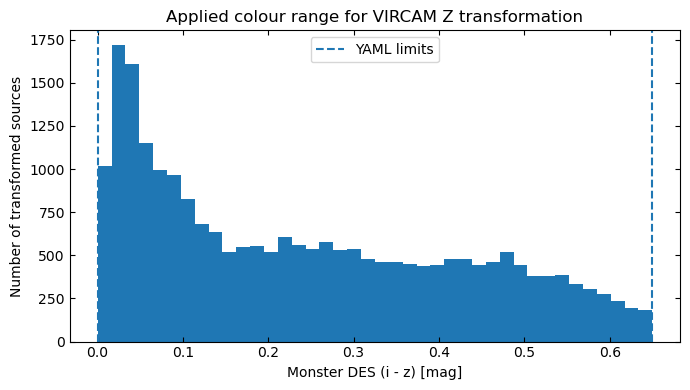

In [18]:
z_colors_all = np.concatenate(
    z_colors_all
)

fig, ax = plt.subplots(
    figsize=(7, 4)
)

ax.hist(
    z_colors_all,
    bins=40,
)

ax.axvline(
    z_transform[
        "color_min"
    ],
    linestyle="--",
    label="YAML limits",
)

ax.axvline(
    z_transform[
        "color_max"
    ],
    linestyle="--",
)

ax.set_xlabel(
    "Monster DES (i - z) [mag]"
)
ax.set_ylabel(
    "Number of transformed sources"
)
ax.set_title(
    "Applied colour range for VIRCAM Z transformation"
)
ax.tick_params(
    direction="in",
    top=True,
    right=True,
)
ax.legend()

plt.tight_layout()
plt.show()

### Applied Y-colour distribution

This is the corresponding Y-band diagnostic. The calibrated Y relation is defined only over the stored DES $z-y$ node interval; the notebook does not extrapolate beyond it.

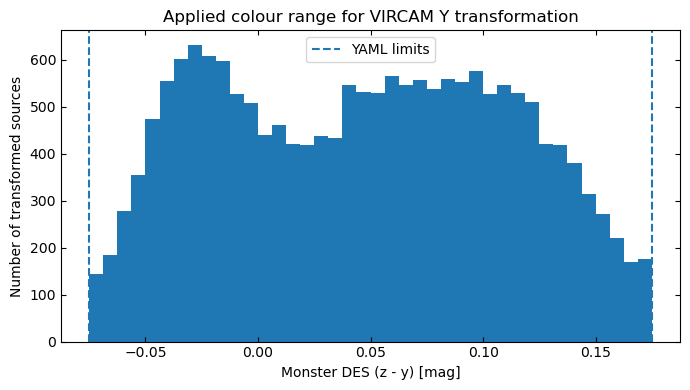

In [19]:
y_colors_all = np.concatenate(
    y_colors_all
)

fig, ax = plt.subplots(
    figsize=(7, 4)
)

ax.hist(
    y_colors_all,
    bins=40,
)

ax.axvline(
    y_transform[
        "color_min"
    ],
    linestyle="--",
    label="YAML limits",
)

ax.axvline(
    y_transform[
        "color_max"
    ],
    linestyle="--",
)

ax.set_xlabel(
    "Monster DES (z - y) [mag]"
)
ax.set_ylabel(
    "Number of transformed sources"
)
ax.set_title(
    "Applied colour range for VIRCAM Y transformation"
)
ax.tick_params(
    direction="in",
    top=True,
    right=True,
)
ax.legend()

plt.tight_layout()
plt.show()

### Match-separation distributions

J/H/Ks use the same matching procedure as Approach 1, so these distributions should reproduce the Approach 1 Gold-match separations.

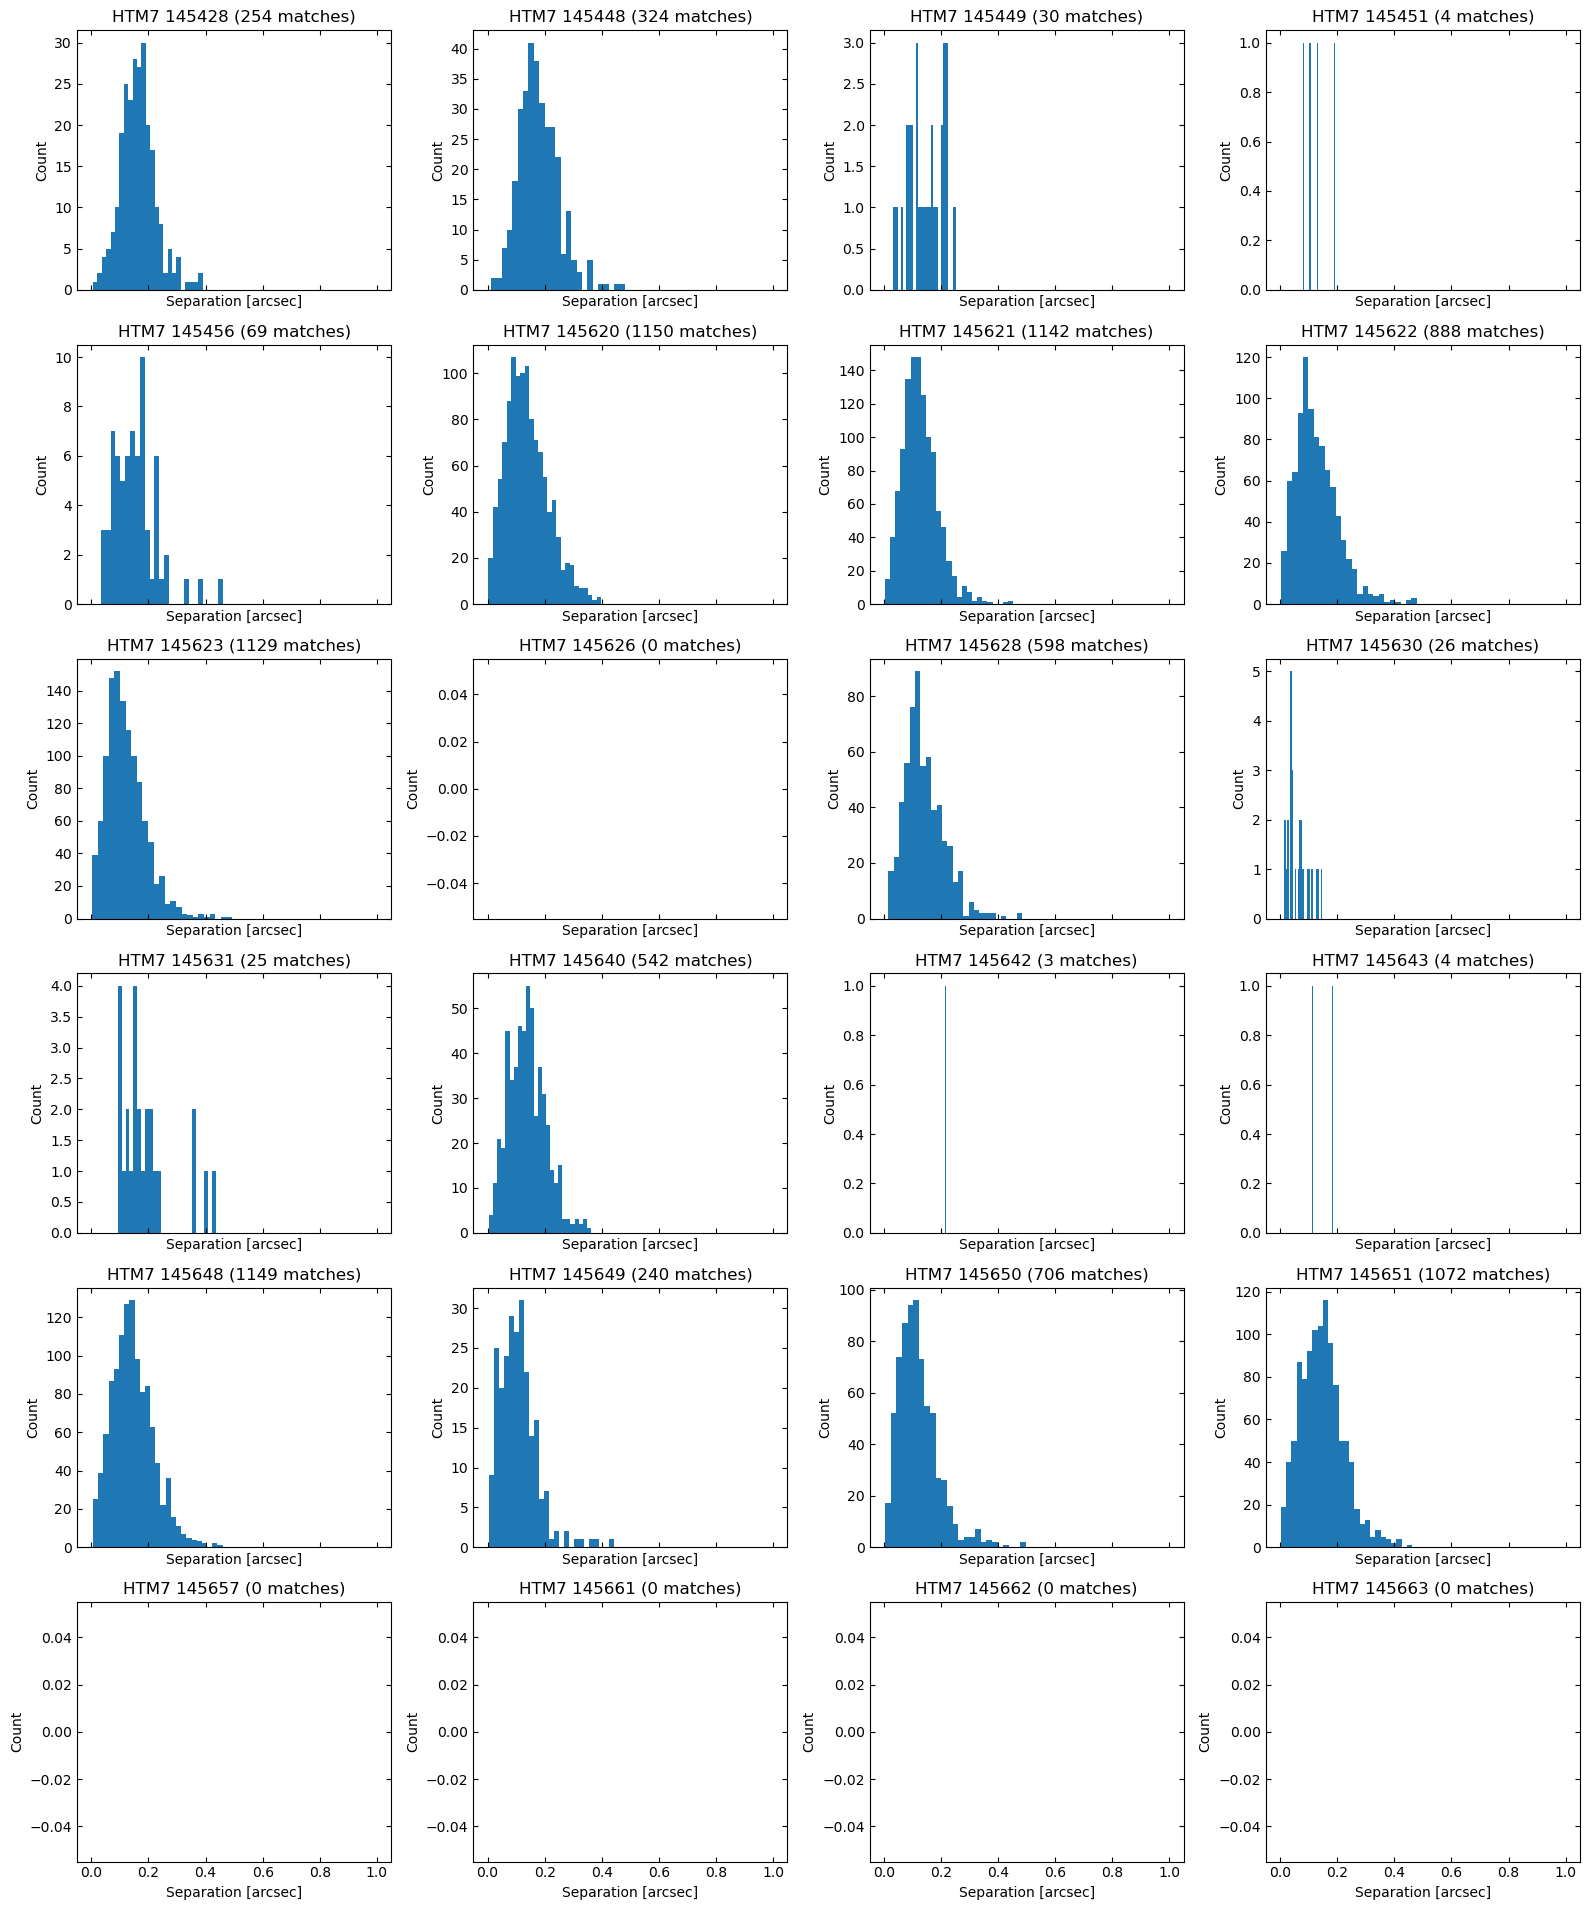

In [20]:
items = sorted(
    all_separations.items(),
    key=lambda item: item[
        0
    ],
)

n_shards = len(
    items
)

ncols = 4

nrows = int(
    np.ceil(
        n_shards
        / ncols
    )
)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(
        16,
        3.2
        * nrows,
    ),
    sharex=True,
    sharey=False,
)

axes = np.atleast_1d(
    axes
).ravel()

for ax, (
    htm_id,
    sep_arcsec,
) in zip(
    axes,
    items,
):

    sep_arcsec = np.asarray(
        sep_arcsec,
        dtype=float,
    )

    sep_arcsec = sep_arcsec[
        np.isfinite(
            sep_arcsec
        )
    ]

    ax.hist(
        sep_arcsec,
        bins=25,
    )

    ax.set_title(
        f"HTM7 {htm_id} "
        f"({len(sep_arcsec)} matches)"
    )

    ax.set_xlabel(
        "Separation [arcsec]"
    )

    ax.set_ylabel(
        "Count"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

for ax in axes[
    n_shards:
]:
    ax.axis(
        "off"
    )

plt.tight_layout()
plt.show()

### Verify output shards, row order, schema, and units

The output validation checks that every expected HTM7 shard exists, source IDs remain in native Monster order, the minimal astrometric/VIRCAM schema is complete, and all VIRCAM fluxes have nJy units.

In [21]:
output_files = sorted(
    outdir.glob(
        "*.fits"
    )
)

output_ids = sorted(
    int(
        path.stem
    )
    for path in output_files
    if path.stem.isdigit()
)

missing_outputs = sorted(
    set(
        htm7_ids
    )
    - set(
        output_ids
    )
)

extra_outputs = sorted(
    set(
        output_ids
    )
    - set(
        htm7_ids
    )
)

print(
    f"Input HTM7 shards:  "
    f"{len(htm7_ids)}"
)

print(
    f"Output HTM7 shards: "
    f"{len(output_ids)}"
)

print(
    "Missing outputs:",
    missing_outputs,
)

print(
    "Unexpected outputs:",
    extra_outputs,
)

if missing_outputs:
    raise RuntimeError(
        "Some expected AP2 HTM7 shards "
        "were not written."
    )

if extra_outputs:
    raise RuntimeError(
        "Unexpected numeric AP2 HTM7 "
        "files are present."
    )

required_output_fields = (
    ASTROMETRY_FIELDS
    + [
        "z2_flux",
        "z2_fluxErr",
        "y2_flux",
        "y2_fluxErr",
        "j_flux",
        "j_fluxErr",
        "h_flux",
        "h_fluxErr",
        "ks_flux",
        "ks_fluxErr",
        "vista_sep_arcsec",
    ]
)

for shard_id in htm7_ids:

    output_table = Table.read(
        outdir
        / f"{shard_id}.fits"
    )

    input_table = monster_tables[
        shard_id
    ]

    if (
        len(
            output_table
        )
        != len(
            input_table
        )
    ):
        raise RuntimeError(
            f"Row-count mismatch for "
            f"HTM7 {shard_id}."
        )

    if not np.array_equal(
        np.asarray(
            output_table[
                "id"
            ],
            dtype=np.int64,
        ),
        np.asarray(
            input_table[
                "id"
            ],
            dtype=np.int64,
        ),
    ):
        raise RuntimeError(
            "Monster source-ID order changed "
            f"for HTM7 {shard_id}."
        )

    missing_fields = [
        name
        for name
        in required_output_fields
        if name
        not in output_table.colnames
    ]

    if missing_fields:
        raise RuntimeError(
            f"HTM7 {shard_id} is missing "
            "output fields: "
            + ", ".join(
                missing_fields
            )
        )

print(
    "\nAll AP2 output shards passed "
    "row, ID, and schema checks."
)

test_output = Table.read(
    outdir
    / f"{htm7_ids[0]}.fits"
)

for name in [
    "z2_flux",
    "y2_flux",
    "j_flux",
    "h_flux",
    "ks_flux",
]:
    print(
        f"{name:8s} unit: "
        f"{test_output[name].unit}"
    )

Input HTM7 shards:  24
Output HTM7 shards: 24
Missing outputs: []
Unexpected outputs: []

All AP2 output shards passed row, ID, and schema checks.
z2_flux  unit: nJy
y2_flux  unit: nJy
j_flux   unit: nJy
h_flux   unit: nJy
ks_flux  unit: nJy


### Global VIRCAM flux QA

For each VIRCAM band, report the number of finite/positive fluxes, median positive flux in nJy, and corresponding median AB magnitude.

These per-band medians are **QA summaries, not colours**. In Approach 2 the transformed Z/Y samples can contain many more Monster sources than the VIDEO-matched J/H/Ks sample, so the five medians are not measured from one identical object set and should not be subtracted from one another for scientific interpretation.

In [22]:
def njy_to_abmag(
    flux_njy,
):
    """Convert positive nJy fluxes to AB magnitudes."""

    flux_njy = np.asarray(
        flux_njy,
        dtype=float,
    )

    mag = np.full(
        len(
            flux_njy
        ),
        np.nan,
        dtype=float,
    )

    good = (
        np.isfinite(
            flux_njy
        )
        & (
            flux_njy
            > 0
        )
    )

    mag[
        good
    ] = (
        31.4
        - 2.5
        * np.log10(
            flux_njy[
                good
            ]
        )
    )

    return mag


bands = [
    "z2",
    "y2",
    "j",
    "h",
    "ks",
]

flux_by_band = {
    band: []
    for band in bands
}

for shard_id in htm7_ids:

    tbl = Table.read(
        outdir
        / f"{shard_id}.fits"
    )

    for band in bands:

        flux_by_band[
            band
        ].append(
            np.asarray(
                tbl[
                    f"{band}_flux"
                ],
                dtype=float,
            )
        )

qa_rows = []

for band in bands:

    flux_all = np.concatenate(
        flux_by_band[
            band
        ]
    )

    finite = np.isfinite(
        flux_all
    )

    positive = (
        finite
        & (
            flux_all
            > 0
        )
    )

    if np.any(
        positive
    ):

        median_flux = float(
            np.median(
                flux_all[
                    positive
                ]
            )
        )

        median_mag = float(
            np.median(
                njy_to_abmag(
                    flux_all[
                        positive
                    ]
                )
            )
        )

    else:

        median_flux = np.nan
        median_mag = np.nan

    qa_rows.append(
        (
            band,
            int(
                np.sum(
                    finite
                )
            ),
            int(
                np.sum(
                    positive
                )
            ),
            median_flux,
            median_mag,
        )
    )

qa_table = Table(
    rows=qa_rows,
    names=[
        "band",
        "n_finite",
        "n_positive",
        "median_flux_nJy",
        "median_AB",
    ],
)

qa_table

band,n_finite,n_positive,median_flux_nJy,median_AB
str2,int64,int64,float64,float64
z2,23324,23324,196677.49329842062,18.16561334263133
y2,18057,18057,377520.62879556004,17.45764828076709
j,9355,9154,189337.33414384178,18.206909399500248
h,9355,9147,203360.40141061906,18.129334023851584
ks,9355,9164,166555.26409499306,18.346104091444285


### Approach 1 consistency check for J/H/Ks and matching

If the Approach 1 products are present, this cell checks the invariant part of the two experiments.

Because Approach 1 and Approach 2 use the same Monster astrometry, effective VIDEO epoch, Gold matching criteria, VIDEO catalogue, aperture columns, and nJy conversion, the following fields should agree exactly, including NaN locations:

- `j_flux`, `j_fluxErr`
- `h_flux`, `h_fluxErr`
- `ks_flux`, `ks_fluxErr`
- `vista_sep_arcsec`

A failure here indicates a matching or catalogue-construction difference unrelated to the Z/Y transformation and should be resolved before interpreting Approach 1 versus Approach 2 photometric results.

In [23]:
shared_fields = [
    "j_flux",
    "j_fluxErr",
    "h_flux",
    "h_fluxErr",
    "ks_flux",
    "ks_fluxErr",
    "vista_sep_arcsec",
]

if ap1_dir.exists():

    for shard_id in htm7_ids:

        ap1_file = (
            ap1_dir
            / f"{shard_id}.fits"
        )

        ap2_file = (
            outdir
            / f"{shard_id}.fits"
        )

        if not ap1_file.exists():
            raise FileNotFoundError(
                ap1_file
            )

        cat_ap1 = Table.read(
            ap1_file
        )

        cat_ap2 = Table.read(
            ap2_file
        )

        ids_ap1 = np.asarray(
            cat_ap1[
                "id"
            ],
            dtype=np.int64,
        )

        ids_ap2 = np.asarray(
            cat_ap2[
                "id"
            ],
            dtype=np.int64,
        )

        if not np.array_equal(
            ids_ap1,
            ids_ap2,
        ):
            raise RuntimeError(
                f"AP1/AP2 ID order differs "
                f"for HTM7 {shard_id}."
            )

        for field in shared_fields:

            values_ap1 = np.asarray(
                cat_ap1[
                    field
                ],
                dtype=float,
            )

            values_ap2 = np.asarray(
                cat_ap2[
                    field
                ],
                dtype=float,
            )

            if not np.allclose(
                values_ap1,
                values_ap2,
                rtol=0.0,
                atol=0.0,
                equal_nan=True,
            ):
                difference = np.abs(
                    values_ap2
                    - values_ap1
                )

                finite_difference = (
                    difference[
                        np.isfinite(
                            difference
                        )
                    ]
                )

                max_difference = (
                    np.max(
                        finite_difference
                    )
                    if len(
                        finite_difference
                    )
                    else np.nan
                )

                raise RuntimeError(
                    f"AP1/AP2 mismatch in "
                    f"{field}, HTM7 {shard_id}; "
                    f"max finite difference = "
                    f"{max_difference}"
                )

    print(
        "AP1/AP2 J/H/Ks and match-separation "
        "consistency check PASSED."
    )

else:

    print(
        "Approach 1 output directory was not found; "
        "shared-field comparison skipped."
    )

AP1/AP2 J/H/Ks and match-separation consistency check PASSED.


### Compare Approach 1 and Approach 2 Z/Y reference fluxes

The direct AP1/AP2 comparison is meaningful only for sources with reliable flux measurements in both catalogues.

For a common source,

$$
\Delta m
=
m_{\rm AP2}-m_{\rm AP1}
=
-2.5\log_{10}
\left(
\frac{F_{\rm AP2}}
     {F_{\rm AP1}}
\right).
$$

AP1 Z/Y come from the matched VIDEO catalogue, whereas AP2 Z/Y come from the Monster-to-VISTA transformations.

Two samples are reported:

1. **all positive finite fluxes**, useful for bookkeeping but vulnerable to very low-S/N VIDEO measurements;
2. **comparison sample**, requiring S/N $\geq 10$ independently in AP1 and AP2.

The plots use the S/N-selected comparison sample. This prevents tiny positive VIDEO fluxes from producing artificial multi-magnitude tails while retaining the unfiltered statistics in the summary table.

The catalogues are first required to have identical Monster IDs in the same order. Masked FITS values are converted explicitly to NaN, avoiding masked-element warnings.

In [24]:
COMPARISON_SNR_MIN = 10.0


def float_array(column):
    """Return a FITS/Astropy column as float with masked values set to NaN."""

    return np.asarray(
        np.ma.filled(
            column,
            np.nan,
        ),
        dtype=float,
    )


def robust_summary(values):
    """Return N, median, NMAD, p16, p84 and robust |residual|>0.3 fraction."""

    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    if len(values) == 0:
        return (
            0,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    median = np.median(
        values
    )

    nmad = (
        1.4826
        * np.median(
            np.abs(
                values
                - median
            )
        )
    )

    p16, p84 = np.percentile(
        values,
        [
            16,
            84,
        ],
    )

    outlier_fraction = np.mean(
        np.abs(
            values
            - median
        )
        > 0.3
    )

    return (
        len(values),
        median,
        nmad,
        p16,
        p84,
        outlier_fraction,
    )


comparison = {
    "Z": {
        "delta_all": [],
        "delta_clean": [],
        "color_clean": [],
        "mag_ap1_clean": [],
        "snr_ap1_clean": [],
        "snr_ap2_clean": [],
    },
    "Y": {
        "delta_all": [],
        "delta_clean": [],
        "color_clean": [],
        "mag_ap1_clean": [],
        "snr_ap1_clean": [],
        "snr_ap2_clean": [],
    },
}


if not ap1_dir.exists():
    raise FileNotFoundError(
        "Approach 1 output directory is required for "
        f"the AP1/AP2 comparison: {ap1_dir}"
    )


for shard_id in htm7_ids:

    cat_ap1 = Table.read(
        ap1_dir
        / f"{shard_id}.fits"
    )

    cat_ap2 = Table.read(
        outdir
        / f"{shard_id}.fits"
    )

    mon = monster_tables[
        shard_id
    ]

    ids_ap1 = np.asarray(
        cat_ap1[
            "id"
        ],
        dtype=np.int64,
    )

    ids_ap2 = np.asarray(
        cat_ap2[
            "id"
        ],
        dtype=np.int64,
    )

    ids_mon = np.asarray(
        mon[
            "id"
        ],
        dtype=np.int64,
    )

    if not np.array_equal(
        ids_ap1,
        ids_ap2,
    ):
        raise RuntimeError(
            f"AP1/AP2 ID order differs for HTM7 {shard_id}."
        )

    if not np.array_equal(
        ids_ap2,
        ids_mon,
    ):
        raise RuntimeError(
            f"AP2/Monster ID order differs for HTM7 {shard_id}."
        )

    for (
        label,
        field,
        err_field,
        payload,
    ) in [
        (
            "Z",
            "z2_flux",
            "z2_fluxErr",
            z_payload,
        ),
        (
            "Y",
            "y2_flux",
            "y2_fluxErr",
            y_payload,
        ),
    ]:

        flux_ap1 = float_array(
            cat_ap1[
                field
            ]
        )

        err_ap1 = float_array(
            cat_ap1[
                err_field
            ]
        )

        flux_ap2 = float_array(
            cat_ap2[
                field
            ]
        )

        err_ap2 = float_array(
            cat_ap2[
                err_field
            ]
        )

        positive = (
            np.isfinite(
                flux_ap1
            )
            & np.isfinite(
                flux_ap2
            )
            & (
                flux_ap1
                > 0
            )
            & (
                flux_ap2
                > 0
            )
        )

        delta_all = np.full(
            len(
                cat_ap1
            ),
            np.nan,
            dtype=float,
        )

        delta_all[
            positive
        ] = (
            -2.5
            * np.log10(
                flux_ap2[
                    positive
                ]
                / flux_ap1[
                    positive
                ]
            )
        )

        comparison[
            label
        ][
            "delta_all"
        ].append(
            delta_all[
                positive
            ]
        )

        valid_errors = (
            positive
            & np.isfinite(
                err_ap1
            )
            & np.isfinite(
                err_ap2
            )
            & (
                err_ap1
                > 0
            )
            & (
                err_ap2
                > 0
            )
        )

        snr_ap1 = np.full(
            len(
                cat_ap1
            ),
            np.nan,
            dtype=float,
        )

        snr_ap2 = np.full(
            len(
                cat_ap2
            ),
            np.nan,
            dtype=float,
        )

        snr_ap1[
            valid_errors
        ] = (
            flux_ap1[
                valid_errors
            ]
            / err_ap1[
                valid_errors
            ]
        )

        snr_ap2[
            valid_errors
        ] = (
            flux_ap2[
                valid_errors
            ]
            / err_ap2[
                valid_errors
            ]
        )

        clean = (
            valid_errors
            & (
                snr_ap1
                >= COMPARISON_SNR_MIN
            )
            & (
                snr_ap2
                >= COMPARISON_SNR_MIN
            )
        )

        delta_clean = (
            -2.5
            * np.log10(
                flux_ap2[
                    clean
                ]
                / flux_ap1[
                    clean
                ]
            )
        )

        f1 = float_array(
            mon[
                payload[
                    "source_color_field_1"
                ]
            ]
        )

        f2 = float_array(
            mon[
                payload[
                    "source_color_field_2"
                ]
            ]
        )

        color = np.full(
            len(
                mon
            ),
            np.nan,
            dtype=float,
        )

        valid_color = (
            np.isfinite(
                f1
            )
            & np.isfinite(
                f2
            )
            & (
                f1
                > 0
            )
            & (
                f2
                > 0
            )
        )

        color[
            valid_color
        ] = (
            -2.5
            * np.log10(
                f1[
                    valid_color
                ]
                / f2[
                    valid_color
                ]
            )
        )

        mag_ap1 = np.full(
            len(
                cat_ap1
            ),
            np.nan,
            dtype=float,
        )

        mag_ap1[
            positive
        ] = (
            31.4
            - 2.5
            * np.log10(
                flux_ap1[
                    positive
                ]
            )
        )

        comparison[
            label
        ][
            "delta_clean"
        ].append(
            delta_clean
        )

        comparison[
            label
        ][
            "color_clean"
        ].append(
            color[
                clean
            ]
        )

        comparison[
            label
        ][
            "mag_ap1_clean"
        ].append(
            mag_ap1[
                clean
            ]
        )

        comparison[
            label
        ][
            "snr_ap1_clean"
        ].append(
            snr_ap1[
                clean
            ]
        )

        comparison[
            label
        ][
            "snr_ap2_clean"
        ].append(
            snr_ap2[
                clean
            ]
        )


for label in [
    "Z",
    "Y",
]:
    for key in comparison[
        label
    ]:
        comparison[
            label
        ][
            key
        ] = np.concatenate(
            comparison[
                label
            ][
                key
            ]
        )


comparison_rows = []

for label in [
    "Z",
    "Y",
]:

    for sample_name, key in [
        (
            "all positive",
            "delta_all",
        ),
        (
            f"S/N >= {COMPARISON_SNR_MIN:g}",
            "delta_clean",
        ),
    ]:

        (
            n,
            median,
            nmad,
            p16,
            p84,
            outlier_fraction,
        ) = robust_summary(
            comparison[
                label
            ][
                key
            ]
        )

        comparison_rows.append(
            (
                label,
                sample_name,
                n,
                median,
                nmad,
                p16,
                p84,
                outlier_fraction,
            )
        )


comparison_table = Table(
    rows=comparison_rows,
    names=[
        "band",
        "sample",
        "n_common",
        "median_AP2_minus_AP1_mag",
        "nmad_mag",
        "p16_mag",
        "p84_mag",
        "frac_abs_resid_gt_0p3",
    ],
)

display(
    comparison_table
)

band,sample,n_common,median_AP2_minus_AP1_mag,nmad_mag,p16_mag,p84_mag,frac_abs_resid_gt_0p3
str1,str12,int64,float64,float64,float64,float64,float64
Z,all positive,7622,-0.3116176815426006,0.03190488837575628,-0.3417474467002069,-0.2827057208096961,0.03529257412752558
Z,S/N >= 10,7621,-0.3116155579097303,0.03189977025705252,-0.34174055420687754,-0.282704240055235,0.03516598871539168
Y,all positive,6060,-0.32283811269262963,0.020615032012653224,-0.34685385123270146,-0.30334499152738725,0.025907590759075907
Y,S/N >= 10,6059,-0.32283400121867506,0.020604440198866255,-0.34684053617750293,-0.3033389760855046,0.02574682290807064


### Z reference-flux comparison

The histogram uses only the common Z sources with S/N $\geq 10$ in both approaches. The vertical lines mark zero and the sample median; the legend also reports the NMAD.

The all-positive sample remains available in the summary table above and is not silently discarded.

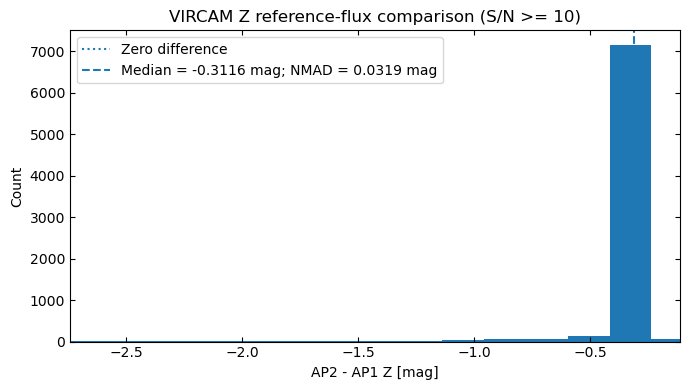

In [25]:
delta_z = comparison[
    "Z"
][
    "delta_clean"
]

if len(
    delta_z
) > 0:

    median_z = np.nanmedian(
        delta_z
    )

    nmad_z = (
        1.4826
        * np.nanmedian(
            np.abs(
                delta_z
                - median_z
            )
        )
    )

    lo_z, hi_z = np.nanpercentile(
        delta_z,
        [
            0.5,
            99.5,
        ],
    )

    pad_z = max(
        0.02,
        0.05
        * (
            hi_z
            - lo_z
        ),
    )

    fig, ax = plt.subplots(
        figsize=(
            7,
            4,
        )
    )

    ax.hist(
        delta_z[
            np.isfinite(
                delta_z
            )
        ],
        bins=50,
    )

    ax.axvline(
        0.0,
        linestyle=":",
        label="Zero difference",
    )

    ax.axvline(
        median_z,
        linestyle="--",
        label=(
            f"Median = {median_z:+.4f} mag; "
            f"NMAD = {nmad_z:.4f} mag"
        ),
    )

    ax.set_xlim(
        lo_z
        - pad_z,
        hi_z
        + pad_z,
    )

    ax.set_xlabel(
        "AP2 - AP1 Z [mag]"
    )

    ax.set_ylabel(
        "Count"
    )

    ax.set_title(
        f"VIRCAM Z reference-flux comparison "
        f"(S/N >= {COMPARISON_SNR_MIN:g})"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

### Y reference-flux comparison

The same S/N-selected comparison is shown separately for Y. Keeping Y separate is important because it uses a different Monster source flux and a substantially narrower calibrated colour interval.

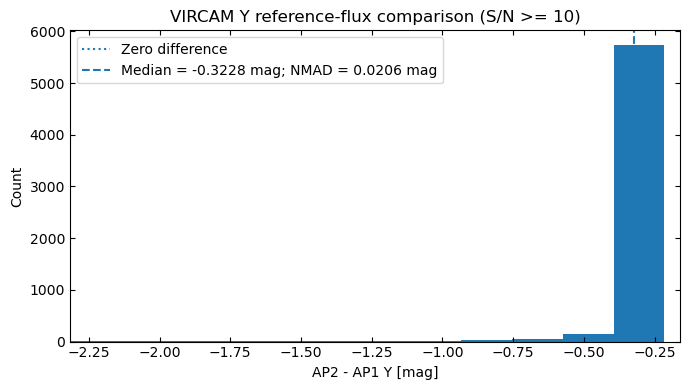

In [26]:
delta_y = comparison[
    "Y"
][
    "delta_clean"
]

if len(
    delta_y
) > 0:

    median_y = np.nanmedian(
        delta_y
    )

    nmad_y = (
        1.4826
        * np.nanmedian(
            np.abs(
                delta_y
                - median_y
            )
        )
    )

    lo_y, hi_y = np.nanpercentile(
        delta_y,
        [
            0.5,
            99.5,
        ],
    )

    pad_y = max(
        0.02,
        0.05
        * (
            hi_y
            - lo_y
        ),
    )

    fig, ax = plt.subplots(
        figsize=(
            7,
            4,
        )
    )

    ax.hist(
        delta_y[
            np.isfinite(
                delta_y
            )
        ],
        bins=50,
    )

    ax.axvline(
        0.0,
        linestyle=":",
        label="Zero difference",
    )

    ax.axvline(
        median_y,
        linestyle="--",
        label=(
            f"Median = {median_y:+.4f} mag; "
            f"NMAD = {nmad_y:.4f} mag"
        ),
    )

    ax.set_xlim(
        lo_y
        - pad_y,
        hi_y
        + pad_y,
    )

    ax.set_xlabel(
        "AP2 - AP1 Y [mag]"
    )

    ax.set_ylabel(
        "Count"
    )

    ax.set_title(
        f"VIRCAM Y reference-flux comparison "
        f"(S/N >= {COMPARISON_SNR_MIN:g})"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

### Z residual versus transformation colour

This diagnostic tests whether the AP2–AP1 Z difference retains a systematic dependence on the exact DES $i-z$ colour used by the Z YAML.

A colour trend would indicate that the transformed Z relation should be revisited even if its overall median offset is small.

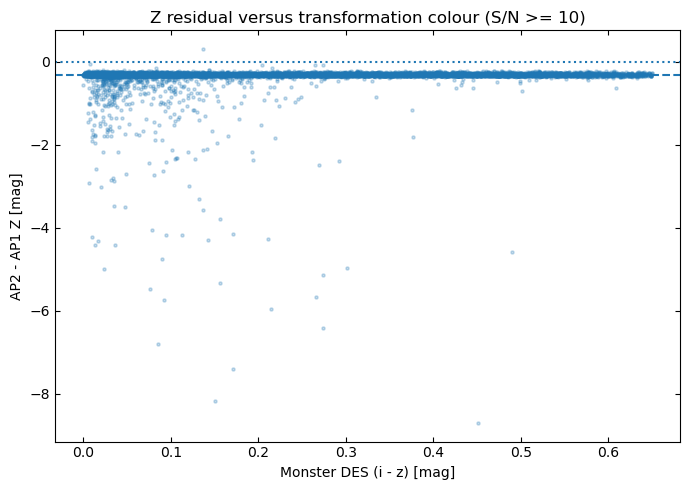

In [27]:
z_color_compare = comparison[
    "Z"
][
    "color_clean"
]

z_delta_compare = comparison[
    "Z"
][
    "delta_clean"
]

good = (
    np.isfinite(
        z_color_compare
    )
    & np.isfinite(
        z_delta_compare
    )
)

if np.any(
    good
):

    fig, ax = plt.subplots(
        figsize=(
            7,
            5,
        )
    )

    ax.scatter(
        z_color_compare[
            good
        ],
        z_delta_compare[
            good
        ],
        s=5,
        alpha=0.25,
    )

    ax.axhline(
        0.0,
        linestyle=":",
    )

    ax.axhline(
        np.nanmedian(
            z_delta_compare[
                good
            ]
        ),
        linestyle="--",
    )

    ax.set_xlabel(
        "Monster DES (i - z) [mag]"
    )

    ax.set_ylabel(
        "AP2 - AP1 Z [mag]"
    )

    ax.set_title(
        f"Z residual versus transformation colour "
        f"(S/N >= {COMPARISON_SNR_MIN:g})"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    plt.tight_layout()
    plt.show()

### Y residual versus transformation colour

This is the corresponding Y-band diagnostic using the exact DES $z-y$ colour required by the Y YAML.

Because the Y calibration range is narrow, this plot is an important check for any residual colour structure across that interval.

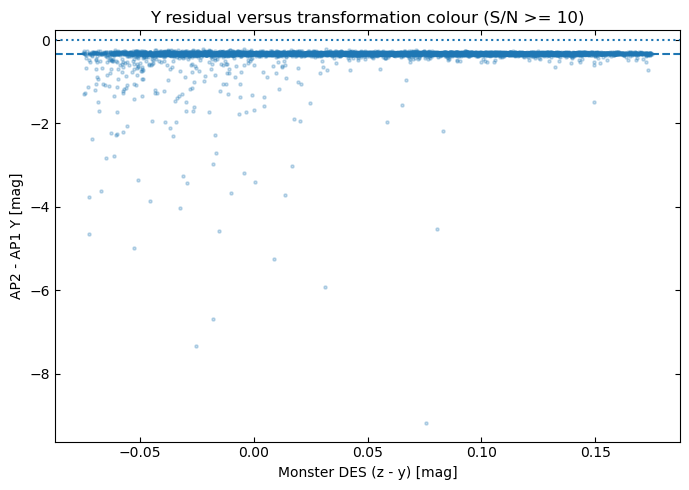

In [28]:
y_color_compare = comparison[
    "Y"
][
    "color_clean"
]

y_delta_compare = comparison[
    "Y"
][
    "delta_clean"
]

good = (
    np.isfinite(
        y_color_compare
    )
    & np.isfinite(
        y_delta_compare
    )
)

if np.any(
    good
):

    fig, ax = plt.subplots(
        figsize=(
            7,
            5,
        )
    )

    ax.scatter(
        y_color_compare[
            good
        ],
        y_delta_compare[
            good
        ],
        s=5,
        alpha=0.25,
    )

    ax.axhline(
        0.0,
        linestyle=":",
    )

    ax.axhline(
        np.nanmedian(
            y_delta_compare[
                good
            ]
        ),
        linestyle="--",
    )

    ax.set_xlabel(
        "Monster DES (z - y) [mag]"
    )

    ax.set_ylabel(
        "AP2 - AP1 Y [mag]"
    )

    ax.set_title(
        f"Y residual versus transformation colour "
        f"(S/N >= {COMPARISON_SNR_MIN:g})"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    plt.tight_layout()
    plt.show()

### Residual versus direct VIDEO magnitude

A final brightness diagnostic checks whether AP2–AP1 differences increase toward the faint end. This helps distinguish a transformation offset from noise in the direct VIDEO reference fluxes.

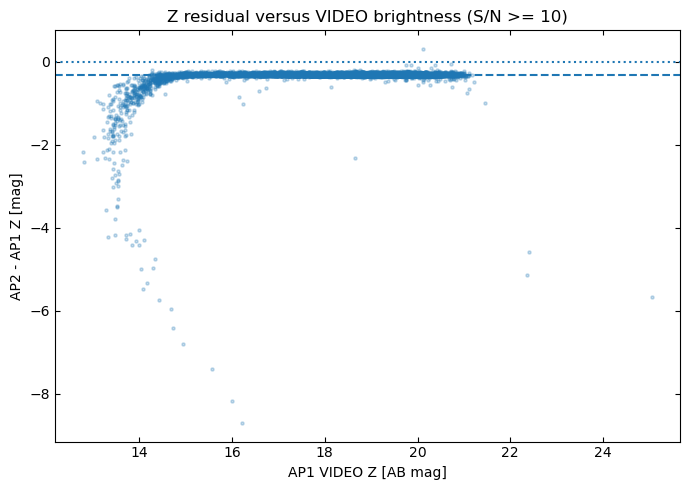

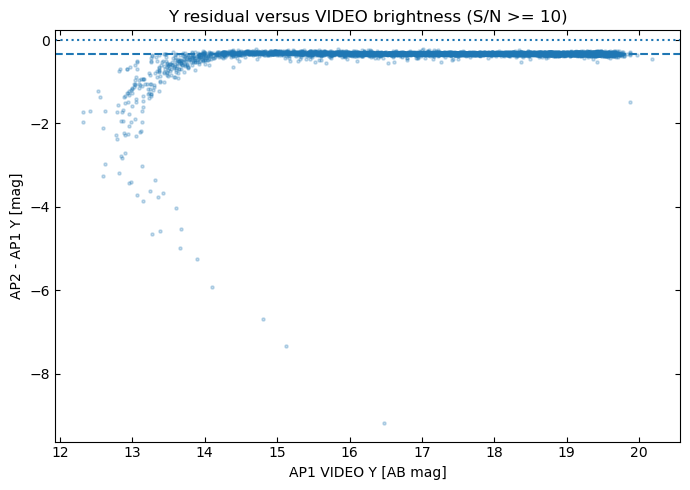

In [29]:
for label in [
    "Z",
    "Y",
]:

    mag = comparison[
        label
    ][
        "mag_ap1_clean"
    ]

    delta = comparison[
        label
    ][
        "delta_clean"
    ]

    good = (
        np.isfinite(
            mag
        )
        & np.isfinite(
            delta
        )
    )

    if not np.any(
        good
    ):
        continue

    fig, ax = plt.subplots(
        figsize=(
            7,
            5,
        )
    )

    ax.scatter(
        mag[
            good
        ],
        delta[
            good
        ],
        s=5,
        alpha=0.25,
    )

    ax.axhline(
        0.0,
        linestyle=":",
    )

    ax.axhline(
        np.nanmedian(
            delta[
                good
            ]
        ),
        linestyle="--",
    )

    ax.set_xlabel(
        f"AP1 VIDEO {label} [AB mag]"
    )

    ax.set_ylabel(
        f"AP2 - AP1 {label} [mag]"
    )

    ax.set_title(
        f"{label} residual versus VIDEO brightness "
        f"(S/N >= {COMPARISON_SNR_MIN:g})"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    plt.tight_layout()
    plt.show()

In [30]:
MAG_MIN = 14.0
MAG_MAX = 19.0

for label in ["Z", "Y"]:

    mag = comparison[label]["mag_ap1_clean"]
    delta = comparison[label]["delta_clean"]

    good = (
        np.isfinite(mag)
        & np.isfinite(delta)
        & (mag > MAG_MIN)
        & (mag < MAG_MAX)
    )

    values = delta[good]

    median = np.median(values)

    nmad = (
        1.4826
        * np.median(
            np.abs(values - median)
        )
    )

    p16, p84 = np.percentile(
        values,
        [16, 84],
    )

    outlier_fraction = np.mean(
        np.abs(values - median) > 0.3
    )

    print(f"{label} band")
    print(f"  N = {len(values)}")
    print(
        f"  median(AP2 - AP1) = "
        f"{median:+.5f} mag"
    )
    print(
        f"  NMAD = {nmad:.5f} mag"
    )
    print(
        f"  16th-84th = "
        f"{p16:+.5f}, {p84:+.5f} mag"
    )
    print(
        f"  fraction |residual-median| > 0.3 = "
        f"{outlier_fraction:.5f}"
    )
    print()

Z band
  N = 4588
  median(AP2 - AP1) = -0.31012 mag
  NMAD = 0.03110 mag
  16th-84th = -0.33915, -0.28153 mag
  fraction |residual-median| > 0.3 = 0.01373

Y band
  N = 4651
  median(AP2 - AP1) = -0.32130 mag
  NMAD = 0.01857 mag
  16th-84th = -0.34072, -0.30295 mag
  fraction |residual-median| > 0.3 = 0.00108



### VIDEO-specific Z/Y transformation test

The original Approach 2 catalogue above is deliberately retained unchanged. Its Z and Y reference fluxes were derived using the VIKING-based Monster-to-VIRCAM transformations, and the comparison with Approach 1 revealed an approximately 0.3 mag systematic offset in both bands.

This result motivated an independent calibration of the same Monster-to-VIRCAM relations using VIDEO DR5 itself. The VIDEO-specific transformations were derived from CDFS, ELAIS-S1, and XMM-LSS with field-balanced colour nodes and leave-one-field-out validation.

Here the new VIDEO-specific YAML files are tested **without overwriting the original Approach 2 products**. For the same Monster rows:

- **AP1** uses the directly matched VIDEO Z/Y aperture fluxes;
- **AP2-VIKING** is the original Approach 2 catalogue constructed above;
- **AP2-VIDEO** is evaluated on-the-fly using the new VIDEO-specific Z/Y transformations.

The main diagnostic is whether replacing only the transformation changes the original AP2−AP1 offset while leaving the source matching and J/H/Ks construction untouched.

For a fair three-way comparison, an additional common sample requires positive finite fluxes, positive finite uncertainties, and S/N $\geq 10$ in AP1, AP2-VIKING, and AP2-VIDEO.

In [31]:
z_video_yaml = (
    calibration_dir
    / "Monster_to_VIDEO_band_z.yaml"
)

y_video_yaml = (
    calibration_dir
    / "Monster_to_VIDEO_band_y.yaml"
)


for path in [
    z_video_yaml,
    y_video_yaml,
]:
    if not path.exists():
        raise FileNotFoundError(
            path
        )


with z_video_yaml.open() as stream:
    z_video_payload = yaml.safe_load(
        stream
    )

with y_video_yaml.open() as stream:
    y_video_payload = yaml.safe_load(
        stream
    )


z_video_transform = validate_transform_yaml(
    z_video_payload,
    EXPECTED_TRANSFORMS["Z"],
    "VIDEO Z",
)

y_video_transform = validate_transform_yaml(
    y_video_payload,
    EXPECTED_TRANSFORMS["Y"],
    "VIDEO Y",
)


print("Original AP2 transformations:")
print(
    f"  Z: {z_yaml}"
)
print(
    f"     colour range = "
    f"{z_transform['color_min']:.3f} "
    f"to {z_transform['color_max']:.3f}"
)
print(
    f"  Y: {y_yaml}"
)
print(
    f"     colour range = "
    f"{y_transform['color_min']:.3f} "
    f"to {y_transform['color_max']:.3f}"
)

print("\nVIDEO-specific test transformations:")
print(
    f"  Z: {z_video_yaml}"
)
print(
    f"     colour range = "
    f"{z_video_transform['color_min']:.3f} "
    f"to {z_video_transform['color_max']:.3f}"
)
print(
    f"  Y: {y_video_yaml}"
)
print(
    f"     colour range = "
    f"{y_video_transform['color_min']:.3f} "
    f"to {y_video_transform['color_max']:.3f}"
)

Original AP2 transformations:
  Z: ../Monster/Monster_to_VISTA_band_z.yaml
     colour range = 0.000 to 0.650
  Y: ../Monster/Monster_to_VISTA_band_y.yaml
     colour range = -0.075 to 0.175

VIDEO-specific test transformations:
  Z: ../Monster/Monster_to_VIDEO_band_z.yaml
     colour range = 0.000 to 0.650
  Y: ../Monster/Monster_to_VIDEO_band_y.yaml
     colour range = -0.050 to 0.175


### Evaluate AP2-VIDEO and construct the comparison samples

The VIDEO-specific transformations use the same ratio convention as the original calibration,

$$
R =
\frac{F_{\rm Monster}}
     {F_{\rm VIRCAM}},
$$

so the target VIRCAM flux is again recovered by division,

$$
F_{\rm VIRCAM}
=
\frac{F_{\rm Monster}}{R}.
$$

The existing `evaluate_transform` function is therefore reused without modification.

Two samples are retained:

1. **AP1/AP2-VIDEO sample:** S/N $\geq 10$ in AP1 and AP2-VIDEO, directly analogous to the original AP1/AP2 comparison;
2. **three-way common sample:** S/N $\geq 10$ simultaneously in AP1, AP2-VIKING, and AP2-VIDEO, allowing the effect of changing only the transformation to be measured on exactly the same sources.

In [32]:
video_test = {
    "Z": {
        "delta_video_ap1": [],
        "delta_viking_ap1_common": [],
        "delta_video_ap1_common": [],
        "delta_video_viking_common": [],
        "mag_ap1": [],
        "mag_ap1_common": [],
        "color": [],
        "color_common": [],
    },
    "Y": {
        "delta_video_ap1": [],
        "delta_viking_ap1_common": [],
        "delta_video_ap1_common": [],
        "delta_video_viking_common": [],
        "mag_ap1": [],
        "mag_ap1_common": [],
        "color": [],
        "color_common": [],
    },
}


for shard_id in htm7_ids:

    cat_ap1 = Table.read(
        ap1_dir
        / f"{shard_id}.fits"
    )

    cat_ap2_viking = Table.read(
        outdir
        / f"{shard_id}.fits"
    )

    mon = monster_tables[
        shard_id
    ]

    ids_ap1 = np.asarray(
        cat_ap1["id"],
        dtype=np.int64,
    )

    ids_viking = np.asarray(
        cat_ap2_viking["id"],
        dtype=np.int64,
    )

    ids_mon = np.asarray(
        mon["id"],
        dtype=np.int64,
    )

    if not (
        np.array_equal(
            ids_ap1,
            ids_viking,
        )
        and np.array_equal(
            ids_ap1,
            ids_mon,
        )
    ):
        raise RuntimeError(
            f"ID order mismatch for HTM7 {shard_id}."
        )


    for (
        label,
        flux_field,
        err_field,
        video_transform,
    ) in [
        (
            "Z",
            "z2_flux",
            "z2_fluxErr",
            z_video_transform,
        ),
        (
            "Y",
            "y2_flux",
            "y2_fluxErr",
            y_video_transform,
        ),
    ]:

        flux_ap1 = float_array(
            cat_ap1[
                flux_field
            ]
        )

        err_ap1 = float_array(
            cat_ap1[
                err_field
            ]
        )

        flux_viking = float_array(
            cat_ap2_viking[
                flux_field
            ]
        )

        err_viking = float_array(
            cat_ap2_viking[
                err_field
            ]
        )

        (
            flux_video,
            err_video,
            video_diag,
        ) = evaluate_transform(
            mon,
            video_transform,
        )


        valid_ap1 = (
            np.isfinite(flux_ap1)
            & np.isfinite(err_ap1)
            & (flux_ap1 > 0)
            & (err_ap1 > 0)
        )

        valid_viking = (
            np.isfinite(flux_viking)
            & np.isfinite(err_viking)
            & (flux_viking > 0)
            & (err_viking > 0)
        )

        valid_video = (
            np.isfinite(flux_video)
            & np.isfinite(err_video)
            & (flux_video > 0)
            & (err_video > 0)
        )


        snr_ap1 = np.full(
            len(mon),
            np.nan,
            dtype=float,
        )

        snr_viking = np.full(
            len(mon),
            np.nan,
            dtype=float,
        )

        snr_video = np.full(
            len(mon),
            np.nan,
            dtype=float,
        )


        snr_ap1[
            valid_ap1
        ] = (
            flux_ap1[
                valid_ap1
            ]
            / err_ap1[
                valid_ap1
            ]
        )

        snr_viking[
            valid_viking
        ] = (
            flux_viking[
                valid_viking
            ]
            / err_viking[
                valid_viking
            ]
        )

        snr_video[
            valid_video
        ] = (
            flux_video[
                valid_video
            ]
            / err_video[
                valid_video
            ]
        )


        # Direct AP1 versus new VIDEO-transform comparison.
        pair = (
            valid_ap1
            & valid_video
            & (
                snr_ap1
                >= COMPARISON_SNR_MIN
            )
            & (
                snr_video
                >= COMPARISON_SNR_MIN
            )
        )


        # Exactly the same sources in all three approaches.
        common = (
            pair
            & valid_viking
            & (
                snr_viking
                >= COMPARISON_SNR_MIN
            )
        )


        delta_video_ap1 = (
            -2.5
            * np.log10(
                flux_video[
                    pair
                ]
                / flux_ap1[
                    pair
                ]
            )
        )

        delta_viking_ap1_common = (
            -2.5
            * np.log10(
                flux_viking[
                    common
                ]
                / flux_ap1[
                    common
                ]
            )
        )

        delta_video_ap1_common = (
            -2.5
            * np.log10(
                flux_video[
                    common
                ]
                / flux_ap1[
                    common
                ]
            )
        )

        delta_video_viking_common = (
            -2.5
            * np.log10(
                flux_video[
                    common
                ]
                / flux_viking[
                    common
                ]
            )
        )


        mag_ap1 = np.full(
            len(mon),
            np.nan,
            dtype=float,
        )

        positive_ap1 = (
            np.isfinite(flux_ap1)
            & (flux_ap1 > 0)
        )

        mag_ap1[
            positive_ap1
        ] = (
            31.4
            - 2.5
            * np.log10(
                flux_ap1[
                    positive_ap1
                ]
            )
        )


        video_test[
            label
        ][
            "delta_video_ap1"
        ].append(
            delta_video_ap1
        )

        video_test[
            label
        ][
            "delta_viking_ap1_common"
        ].append(
            delta_viking_ap1_common
        )

        video_test[
            label
        ][
            "delta_video_ap1_common"
        ].append(
            delta_video_ap1_common
        )

        video_test[
            label
        ][
            "delta_video_viking_common"
        ].append(
            delta_video_viking_common
        )

        video_test[
            label
        ][
            "mag_ap1"
        ].append(
            mag_ap1[
                pair
            ]
        )

        video_test[
            label
        ][
            "mag_ap1_common"
        ].append(
            mag_ap1[
                common
            ]
        )

        video_test[
            label
        ][
            "color"
        ].append(
            video_diag[
                "color"
            ][
                pair
            ]
        )

        video_test[
            label
        ][
            "color_common"
        ].append(
            video_diag[
                "color"
            ][
                common
            ]
        )


for label in [
    "Z",
    "Y",
]:

    for key in video_test[
        label
    ]:

        video_test[
            label
        ][
            key
        ] = np.concatenate(
            video_test[
                label
            ][
                key
            ]
        )

In [33]:
test_rows = []

for label in [
    "Z",
    "Y",
]:

    for name, key in [
        (
            "AP2-VIDEO - AP1",
            "delta_video_ap1",
        ),
        (
            "AP2-VIKING - AP1, common",
            "delta_viking_ap1_common",
        ),
        (
            "AP2-VIDEO - AP1, common",
            "delta_video_ap1_common",
        ),
        (
            "AP2-VIDEO - AP2-VIKING, common",
            "delta_video_viking_common",
        ),
    ]:

        (
            n,
            median,
            nmad,
            p16,
            p84,
            outlier_fraction,
        ) = robust_summary(
            video_test[
                label
            ][
                key
            ]
        )

        test_rows.append(
            (
                label,
                name,
                n,
                median,
                nmad,
                p16,
                p84,
                outlier_fraction,
            )
        )


video_test_table = Table(
    rows=test_rows,
    names=[
        "band",
        "comparison",
        "N",
        "median_mag",
        "NMAD_mag",
        "p16_mag",
        "p84_mag",
        "frac_abs_resid_gt_0p3",
    ],
)

display(
    video_test_table
)

band,comparison,N,median_mag,NMAD_mag,p16_mag,p84_mag,frac_abs_resid_gt_0p3
str1,str30,int64,float64,float64,float64,float64,float64
Z,AP2-VIDEO - AP1,7621,-0.005173600390553407,0.03167948720518958,-0.03516906805282922,0.024290241327100795,0.03542842146699908
Z,"AP2-VIKING - AP1, common",7621,-0.3116155579097303,0.03189977025705252,-0.34174055420687754,-0.282704240055235,0.03516598871539168
Z,"AP2-VIDEO - AP1, common",7621,-0.005173600390553407,0.03167948720518958,-0.03516906805282922,0.024290241327100795,0.03542842146699908
Z,"AP2-VIDEO - AP2-VIKING, common",7621,0.30564378901194456,0.0020053963398777895,0.3043066407193438,0.30839801256747296,0.0
Y,AP2-VIDEO - AP1,5759,-0.01152563085655221,0.019357412175343328,-0.0337438324578554,0.007010067077426811,0.01771140823059559
Y,"AP2-VIKING - AP1, common",5759,-0.32271374691316335,0.02003342013589421,-0.3455256373324398,-0.30363545315492335,0.017885049487758292
Y,"AP2-VIDEO - AP1, common",5759,-0.01152563085655221,0.019357412175343328,-0.0337438324578554,0.007010067077426811,0.01771140823059559
Y,"AP2-VIDEO - AP2-VIKING, common",5759,0.3100587662166564,0.003357747734794502,0.3073217873803671,0.31720976031587783,0.0


In [34]:
VIDEO_TEST_MAG_MIN = 14.0
VIDEO_TEST_MAG_MAX = 19.0


for label in [
    "Z",
    "Y",
]:

    mag = video_test[
        label
    ][
        "mag_ap1"
    ]

    delta = video_test[
        label
    ][
        "delta_video_ap1"
    ]

    good = (
        np.isfinite(
            mag
        )
        & np.isfinite(
            delta
        )
        & (
            mag
            > VIDEO_TEST_MAG_MIN
        )
        & (
            mag
            < VIDEO_TEST_MAG_MAX
        )
    )

    values = delta[
        good
    ]

    (
        n,
        median,
        nmad,
        p16,
        p84,
        outlier_fraction,
    ) = robust_summary(
        values
    )

    print(
        f"{label} band — VIDEO-specific transformation"
    )
    print(
        f"  N = {n}"
    )
    print(
        f"  median(AP2-VIDEO - AP1) = "
        f"{median:+.5f} mag"
    )
    print(
        f"  NMAD = {nmad:.5f} mag"
    )
    print(
        f"  16th-84th = "
        f"{p16:+.5f}, {p84:+.5f} mag"
    )
    print(
        f"  fraction |residual-median| > 0.3 = "
        f"{outlier_fraction:.5f}"
    )
    print()

Z band — VIDEO-specific transformation
  N = 4588
  median(AP2-VIDEO - AP1) = -0.00377 mag
  NMAD = 0.03091 mag
  16th-84th = -0.03269, +0.02518 mag
  fraction |residual-median| > 0.3 = 0.01395

Y band — VIDEO-specific transformation
  N = 4469
  median(AP2-VIDEO - AP1) = -0.01021 mag
  NMAD = 0.01766 mag
  16th-84th = -0.02890, +0.00729 mag
  fraction |residual-median| > 0.3 = 0.00112



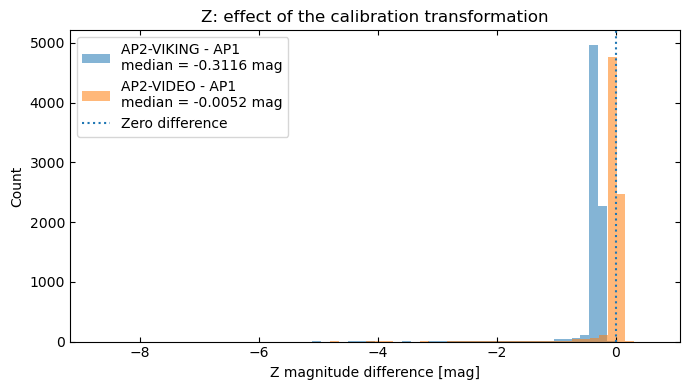

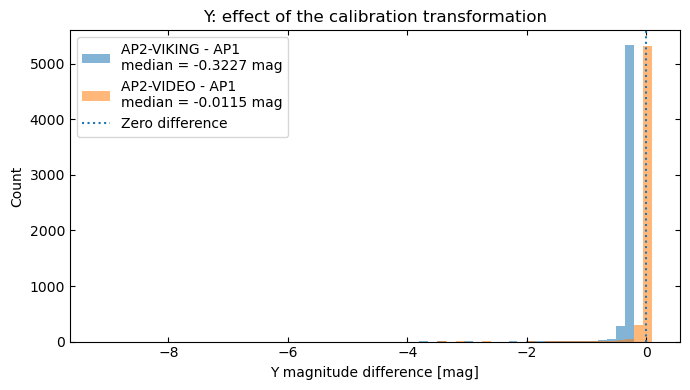

In [35]:
for label in [
    "Z",
    "Y",
]:

    delta_viking = video_test[
        label
    ][
        "delta_viking_ap1_common"
    ]

    delta_video = video_test[
        label
    ][
        "delta_video_ap1_common"
    ]

    good = (
        np.isfinite(
            delta_viking
        )
        & np.isfinite(
            delta_video
        )
    )

    if not np.any(
        good
    ):
        continue


    fig, ax = plt.subplots(
        figsize=(
            7,
            4,
        )
    )

    ax.hist(
        delta_viking[
            good
        ],
        bins=60,
        alpha=0.55,
        label=(
            "AP2-VIKING - AP1\n"
            f"median = "
            f"{np.median(delta_viking[good]):+.4f} mag"
        ),
    )

    ax.hist(
        delta_video[
            good
        ],
        bins=60,
        alpha=0.55,
        label=(
            "AP2-VIDEO - AP1\n"
            f"median = "
            f"{np.median(delta_video[good]):+.4f} mag"
        ),
    )

    ax.axvline(
        0.0,
        linestyle=":",
        label="Zero difference",
    )

    ax.set_xlabel(
        f"{label} magnitude difference [mag]"
    )

    ax.set_ylabel(
        "Count"
    )

    ax.set_title(
        f"{label}: effect of the calibration transformation"
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

## Final pipeline-ready ELAIS-S1 reference catalogues

The cell:

- preserves/copies the existing AP1 output under the explicit final name video_elais_ap1;
- reads each existing AP2 shard;
- verifies that its IDs are still identical to the native Monster rows;
- computes new Z/Y using z_video_transform and y_video_transform;
- keeps J/H/Ks and vista_sep_arcsec exactly as produced by the cross-match;
- recreates a fresh contiguous LSST SimpleCatalog;
- overwrites video_elais_ap2/.../*.fits;
- performs basic verification at the end.

In [36]:
import shutil


# --------------------------------------------------
# Final directory names used by the pipeline
# --------------------------------------------------

final_ap1_dir = Path(
    "data/video_elais_ap1/the_monster_20250219_vista"
)

final_ap2_dir = Path(
    "data/video_elais_ap2/the_monster_20250219_vista"
)

final_ap1_dir.mkdir(
    parents=True,
    exist_ok=True,
)

final_ap2_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------
# Preserve Approach 1 under the explicit final name
# --------------------------------------------------

ap1_source_files = sorted(
    ap1_dir.glob("*.fits")
)

if len(ap1_source_files) != len(htm7_ids):
    raise RuntimeError(
        "Unexpected number of Approach 1 shards: "
        f"{len(ap1_source_files)}; "
        f"expected {len(htm7_ids)}."
    )


# Remove only old FITS shards from the final AP1 directory.
for path in final_ap1_dir.glob("*.fits"):
    path.unlink()


for source in ap1_source_files:

    destination = (
        final_ap1_dir
        / source.name
    )

    shutil.copy2(
        source,
        destination,
    )


print(
    "Approach 1 copied to:"
)
print(
    f"  {final_ap1_dir}"
)


# --------------------------------------------------
# Rebuild final Approach 2
#
# Z/Y   : VIDEO-specific Monster transformations
# J/H/Ks: existing VIDEO Gold cross-match values
# --------------------------------------------------

final_build_rows = []


for shard_id in htm7_ids:

    mon = monster_tables[
        shard_id
    ]

    old_ap2_path = (
        outdir
        / f"{shard_id}.fits"
    )

    if not old_ap2_path.exists():
        raise FileNotFoundError(
            old_ap2_path
        )


    # This catalogue contains the already validated
    # VIDEO Gold-match J/H/Ks measurements.
    old_ap2 = Table.read(
        old_ap2_path
    )


    monster_ids = np.asarray(
        mon["id"],
        dtype=np.int64,
    )

    old_ap2_ids = np.asarray(
        old_ap2["id"],
        dtype=np.int64,
    )


    if not np.array_equal(
        monster_ids,
        old_ap2_ids,
    ):
        raise RuntimeError(
            f"ID/order mismatch for HTM7 {shard_id}."
        )


    n_monster = len(
        mon
    )


    # --------------------------------------------------
    # Final Z/Y from VIDEO-specific transformations
    # --------------------------------------------------

    (
        z2_flux,
        z2_flux_err,
        z_diag,
    ) = evaluate_transform(
        mon,
        z_video_transform,
    )

    (
        y2_flux,
        y2_flux_err,
        y_diag,
    ) = evaluate_transform(
        mon,
        y_video_transform,
    )


    # --------------------------------------------------
    # Preserve the J/H/Ks Gold-match measurements
    # --------------------------------------------------

    jhk_values = {}

    for name in [
        "j_flux",
        "j_fluxErr",
        "h_flux",
        "h_fluxErr",
        "ks_flux",
        "ks_fluxErr",
    ]:

        jhk_values[
            name
        ] = float_array(
            old_ap2[
                name
            ]
        )


    vista_sep_arcsec = float_array(
        old_ap2[
            "vista_sep_arcsec"
        ]
    )


    # --------------------------------------------------
    # Build a new contiguous LSST reference catalogue
    # --------------------------------------------------

    catalog = afwTable.SimpleCatalog(
        schema
    )

    coord_key = (
        catalog.getCoordKey()
    )

    catalog.reserve(
        n_monster
    )


    for index in range(
        n_monster
    ):

        record = catalog.addNew()


        source_id = mon[
            "id"
        ][
            index
        ]

        if not np.isfinite(
            source_id
        ):
            raise RuntimeError(
                f"Non-finite Monster ID in "
                f"HTM7 {shard_id}, row {index}."
            )


        record.setId(
            int(
                source_id
            )
        )


        ra = float(
            mon[
                "coord_ra"
            ][
                index
            ]
        )

        dec = float(
            mon[
                "coord_dec"
            ][
                index
            ]
        )


        record.set(
            coord_key,
            SpherePoint(
                ra,
                dec,
                radians,
            ),
        )


        # Native Monster astrometry.
        for name in [
            "coord_raErr",
            "coord_decErr",
            "epoch",
            "pm_ra",
            "pm_dec",
            "pm_raErr",
            "pm_decErr",
            "parallax",
            "parallaxErr",
        ]:

            value = mon[
                name
            ][
                index
            ]

            if np.ma.is_masked(
                value
            ):
                value = np.nan

            record.set(
                scalar_keys[
                    name
                ],
                float(
                    value
                ),
            )


        # VIDEO-specific transformed Z/Y.
        record.set(
            scalar_keys[
                "z2_flux"
            ],
            float(
                z2_flux[
                    index
                ]
            ),
        )

        record.set(
            scalar_keys[
                "z2_fluxErr"
            ],
            float(
                z2_flux_err[
                    index
                ]
            ),
        )

        record.set(
            scalar_keys[
                "y2_flux"
            ],
            float(
                y2_flux[
                    index
                ]
            ),
        )

        record.set(
            scalar_keys[
                "y2_fluxErr"
            ],
            float(
                y2_flux_err[
                    index
                ]
            ),
        )


        # VIDEO J/H/Ks from the Gold cross-match.
        for (
            name,
            values,
        ) in jhk_values.items():

            record.set(
                scalar_keys[
                    name
                ],
                float(
                    values[
                        index
                    ]
                ),
            )


        record.set(
            scalar_keys[
                "vista_sep_arcsec"
            ],
            float(
                vista_sep_arcsec[
                    index
                ]
            ),
        )


    # --------------------------------------------------
    # Replace the old VIKING-Z/Y AP2 shard
    # --------------------------------------------------

    outname = (
        final_ap2_dir
        / f"{shard_id}.fits"
    )

    if outname.exists():
        outname.unlink()


    catalog.writeFits(
        str(
            outname
        )
    )


    n_jhk = int(
        np.count_nonzero(
            np.isfinite(
                vista_sep_arcsec
            )
        )
    )

    n_z = int(
        np.count_nonzero(
            z_diag[
                "good_flux"
            ]
        )
    )

    n_y = int(
        np.count_nonzero(
            y_diag[
                "good_flux"
            ]
        )
    )


    final_build_rows.append(
        (
            shard_id,
            n_monster,
            n_jhk,
            n_z,
            n_y,
        )
    )


    print(
        f"HTM7 {shard_id}: "
        f"rows={n_monster:5d}  "
        f"JHK={n_jhk:5d}  "
        f"Z_VIDEO={n_z:5d}  "
        f"Y_VIDEO={n_y:5d}"
    )


# --------------------------------------------------
# Final verification
# --------------------------------------------------

final_build_summary = Table(
    rows=final_build_rows,
    names=[
        "htm7",
        "monster_rows",
        "gold_jhk_matches",
        "valid_video_z",
        "valid_video_y",
    ],
)


print(
    "\nFinal Approach 2 summary:"
)

display(
    final_build_summary
)


ap1_final_files = sorted(
    final_ap1_dir.glob("*.fits")
)

ap2_final_files = sorted(
    final_ap2_dir.glob("*.fits")
)


if len(ap1_final_files) != len(
    htm7_ids
):
    raise RuntimeError(
        "Final AP1 shard count is incorrect."
    )


if len(ap2_final_files) != len(
    htm7_ids
):
    raise RuntimeError(
        "Final AP2 shard count is incorrect."
    )


# Verify IDs and final schema for every AP2 shard.
for shard_id in htm7_ids:

    path = (
        final_ap2_dir
        / f"{shard_id}.fits"
    )

    check = Table.read(
        path
    )

    expected_ids = np.asarray(
        monster_tables[
            shard_id
        ][
            "id"
        ],
        dtype=np.int64,
    )

    actual_ids = np.asarray(
        check[
            "id"
        ],
        dtype=np.int64,
    )

    if not np.array_equal(
        expected_ids,
        actual_ids,
    ):
        raise RuntimeError(
            f"Final AP2 ID mismatch "
            f"for HTM7 {shard_id}."
        )


print(
    "\nFinal pipeline-ready reference catalogues:"
)

print(
    f"  AP1: {final_ap1_dir}"
)

print(
    f"  AP2: {final_ap2_dir}"
)

print(
    "\nAP2 Z/Y now use the VIDEO-specific YAMLs."
)

print(
    "AP2 J/H/Ks retain the validated VIDEO Gold cross-match."
)

Approach 1 copied to:
  data/video_elais_ap1/the_monster_20250219_vista
HTM7 145428: rows= 1562  JHK=  254  Z_VIDEO=  992  Y_VIDEO=  770
HTM7 145448: rows= 1477  JHK=  324  Z_VIDEO= 1028  Y_VIDEO=  758
HTM7 145449: rows= 1535  JHK=   30  Z_VIDEO= 1075  Y_VIDEO=  732
HTM7 145451: rows= 1375  JHK=    4  Z_VIDEO=  959  Y_VIDEO=  674
HTM7 145456: rows= 1437  JHK=   69  Z_VIDEO=  932  Y_VIDEO=  708
HTM7 145620: rows= 1496  JHK= 1150  Z_VIDEO= 1072  Y_VIDEO=  774
HTM7 145621: rows= 1486  JHK= 1142  Z_VIDEO= 1055  Y_VIDEO=  751
HTM7 145622: rows= 1546  JHK=  888  Z_VIDEO= 1043  Y_VIDEO=  733
HTM7 145623: rows= 1406  JHK= 1129  Z_VIDEO= 1020  Y_VIDEO=  711
HTM7 145626: rows= 1433  JHK=    0  Z_VIDEO=  885  Y_VIDEO=  694
HTM7 145628: rows= 1377  JHK=  598  Z_VIDEO=  908  Y_VIDEO=  714
HTM7 145630: rows= 1419  JHK=   26  Z_VIDEO=  933  Y_VIDEO=  702
HTM7 145631: rows= 1392  JHK=   25  Z_VIDEO=  851  Y_VIDEO=  664
HTM7 145640: rows= 1576  JHK=  542  Z_VIDEO=  990  Y_VIDEO=  749
HTM7 145642: rows=

htm7,monster_rows,gold_jhk_matches,valid_video_z,valid_video_y
int64,int64,int64,int64,int64
145428,1562,254,992,770
145448,1477,324,1028,758
145449,1535,30,1075,732
145451,1375,4,959,674
145456,1437,69,932,708
145620,1496,1150,1072,774
145621,1486,1142,1055,751
145622,1546,888,1043,733
145623,1406,1129,1020,711



Final pipeline-ready reference catalogues:
  AP1: data/video_elais_ap1/the_monster_20250219_vista
  AP2: data/video_elais_ap2/the_monster_20250219_vista

AP2 Z/Y now use the VIDEO-specific YAMLs.
AP2 J/H/Ks retain the validated VIDEO Gold cross-match.


### Final calibration choice for the ELAIS-S1 reference catalogues

The original Approach 2 construction used the VIKING-derived Monster-to-VIRCAM Z and Y transformations. This version is retained above because it provides an important reproducibility test and motivated the subsequent VIDEO-specific calibration.

Using the original VIKING transformations, the comparison with the directly matched VIDEO photometry in Approach 1 showed a nearly common normalization offset in both bands. For the clean $14 < m < 19$ sample,

- Z: $\mathrm{AP2}_{\rm VIKING}-\mathrm{AP1} = -0.3101$ mag, with NMAD $=0.0311$ mag;
- Y: $\mathrm{AP2}_{\rm VIKING}-\mathrm{AP1} = -0.3213$ mag, with NMAD $=0.0186$ mag.

This motivated new Monster-to-VIRCAM transformations derived directly from VIDEO DR5 using CDFS, ELAIS-S1, and XMM-LSS. Repeating the AP1/AP2 comparison while changing only the Z/Y transformation gives

- Z: $\mathrm{AP2}_{\rm VIDEO}-\mathrm{AP1} = -0.0038$ mag, with NMAD $=0.0309$ mag;
- Y: $\mathrm{AP2}_{\rm VIDEO}-\mathrm{AP1} = -0.0102$ mag, with NMAD $=0.0177$ mag.

On the common three-way sample, replacing the VIKING transformation by the VIDEO transformation changes the inferred photometry by approximately $+0.306$ mag in Z and $+0.310$ mag in Y. The scatter remains nearly unchanged. The original $\simeq0.3$ mag AP1/AP2 discrepancy is therefore primarily associated with the photometric normalization encoded in the VIKING-derived transformations rather than with the transformation direction, source matching, or random photometric scatter.

For the final ELAIS-S1 reference-catalogue products, the adopted definitions are therefore:

- **Approach 1:** Z, Y, J, H, and Ks are taken directly from the VIDEO Gold cross-match.
- **Approach 2:** Z and Y are predicted from Monster using the VIDEO-specific colour transformations, while J, H, and Ks remain tied directly to the VIDEO Gold cross-match.

The VIKING-based calculation above is deliberately retained as part of the calibration history, but its Z/Y values are not used in the final ELAIS-S1 Approach 2 reference catalogue.

The final pipeline-ready catalogues are stored separately as

`data/video_elais_ap1/the_monster_20250219_vista/`

and

`data/video_elais_ap2/the_monster_20250219_vista/`.